# TEE User Study Analysis (Folowup study)
McKenna McCall, Carolina Carreira

This notebook contains code for performing most of the basic, descriptive analysis and for creating the tables and figures for the paper. It pulls from the full, anonymized CSV file from the survey.

# Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import surveyfieldsfollowup
#import numpy as np

pd.set_option('display.width', 400)
pd.set_option('display.max_columns', 10)

sns.set_theme()

ENCODING = 'utf-8-sig'
RESPONSE_ID = "ResponseId"
EXPORT_DIR = "./export_followup/"
PATH_EXCLUSION = EXPORT_DIR+"exclusions.csv"
PATH_DEMOGRAPHIC_QUAL = EXPORT_DIR+"demographic-recoded.csv"
PATH_WILLINGNESS = EXPORT_DIR+"willingness-recoded.csv"
PATH_QUALITATIVE = EXPORT_DIR+"qualitative_data.csv"

/var/folders/tv/m58r9qz162g9dn43wdl5jk7w0000gq/T/ipykernel_80795/1000018147.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Read data and some basic cleaning

* Read scored data
* Re-label data

In [2]:
# Read data, drop unnecessary qualtrics columns
results = pd.read_csv(EXPORT_DIR+'anonymized_data.csv', encoding=ENCODING)
results.columns = surveyfieldsfollowup.allFields

# Participant demographics

Counts for the number of participants in each demographic/experience category
of interest.

We can use `df.to_latex()` on each of these tables, and then copy and paste them into
one big demographics table for the paper.

In [3]:
def recode_for_regression(df):

  # Recode age into 10 year buckets
  ageMap = {
    '18-24 years old': '18-24',
    '25-34 years old': '25-34',
    '35-44 years old': '35-44',
    '45-54 years old': '45-54',
    '55-64 years old': '55+',
    '65+ years old': '55+',
    'Prefer not to say': 'Prefer not to say'
  }
  df['age_reduced'] = df['age'].apply(lambda age: ageMap[age])


  # Recode education into two buckets
  educationMap = {
    'Associates or technical degree': 'Bachelor or associate degree',
    'Bachelor’s degree': 'Bachelor or associate degree',
    'Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS etc.)': 'Graduate degree',
    'High school diploma or GED': 'High school or equivalent',
    'Some high school or less': 'Have not completed high school',
    'Other': 'Other',
    'Some college, but no degree': 'High school or equivalent',
    'Prefer not to say': 'Prefer not to say'
  }
  df['education_reduced'] = df['education'].apply(lambda edu: educationMap[edu])

  # Recode Medical Job to True or False
  medicalExpMap = {
    'Yes; as a participant': True,
    'Yes; as a researcher': True,
    'Yes, as a participant': True, # follow-up only
    'Yes, as a researcher': True, # follow-up only
    'No': False,
    'I’m not sure/Other': False
  }
  df['previous_medical_research'] = df['demo-medical'].apply(lambda x: medicalExpMap[x])

  # Recode Medical Experience to True or False
  medicalJobMap = {
    'Yes': True,
    'No, but I have been in the past': True,
    'No': False,
    'I’m not sure/Other': False
  }
  df['medical_job'] = df['demo-medical-employ'].apply(lambda x: medicalJobMap[x])

  # Recode ownership of IoT to True or False
  IoTMap = {
    'Yes, and I use the smart features': True,
    'Yes, but I don’t use the smart features': True,
    'No': False,
    "No, but I have in the past": True,
    'I’m not sure/Other': False
  }
  df['IoT_ownership'] = df['demo-iot'].apply(lambda x: IoTMap[x])

  # Recode IoT automation to True or False
  IoTMap = {
    'Yes, I currently use home automation': True,
    'Yes, I have used home automation, but not currently': True,
    'No, I don’t own smart devices': False,
    "No, I do not use home automation, but I do own smart devices": False,
    'I’m not sure/Other': False
  }
  df['IoT_automation'] = df['demo-tap'].apply(lambda x: IoTMap[x])

  # Recode employment in IT field
  TechMap = {
    "Yes": True,
    "No": False,
    "No, but I have been in the past": True,
    "I’m not sure/Other": False
  }
  df['CS_Employment'] = df['demo-cs-employ'].apply(lambda x: TechMap[x])

  # Recode education in CS 
  TechMap = {
    "Yes": True,
    "No": False,
    "I'm not sure/Other": False
  }
  df['CS_Education'] = df['demo-cs-education'].apply(lambda x: TechMap[x])
  
  return df

In [4]:
results = recode_for_regression(results)

In [5]:
def demo_table(column):
  s1 = results[column].value_counts().rename('Count')
  s1c = (100 * s1 / s1.sum()).rename('Percent')
  s1 = pd.DataFrame(s1)
  s1c = pd.DataFrame(s1c)

  return s1.join(s1c).fillna(0).astype({'Count': 'Int64'})

In [6]:
print(demo_table('gender').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
gender &  &  \\
Male & 245 & 49.3 \\
Female & 242 & 48.7 \\
Non-binary / third gender & 8 & 1.6 \\
Prefer not to say & 2 & 0.4 \\
\end{tabular}



In [7]:
print(demo_table('age_reduced').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
age_reduced &  &  \\
25-34 & 164 & 33.0 \\
35-44 & 121 & 24.3 \\
18-24 & 82 & 16.5 \\
45-54 & 81 & 16.3 \\
55+ & 48 & 9.7 \\
Prefer not to say & 1 & 0.2 \\
\end{tabular}



In [8]:
print(demo_table('education_reduced').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
education_reduced &  &  \\
Bachelor or associate degree & 225 & 45.3 \\
High school or equivalent & 184 & 37.0 \\
Graduate degree & 81 & 16.3 \\
Have not completed high school & 5 & 1.0 \\
Prefer not to say & 2 & 0.4 \\
\end{tabular}



In [9]:
print(demo_table('demo-tee').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
demo-tee &  &  \\
No & 461 & 92.8 \\
Yes & 36 & 7.2 \\
\end{tabular}



In [10]:
print(demo_table('CS_Employment').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
CS_Employment &  &  \\
False & 410 & 82.5 \\
True & 87 & 17.5 \\
\end{tabular}



In [11]:
print(demo_table('CS_Education').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
CS_Education &  &  \\
False & 434 & 87.3 \\
True & 63 & 12.7 \\
\end{tabular}



In [12]:
results['demo_CS'] = pd.DataFrame(results[['CS_Employment','CS_Education']]).any(axis=1)
print(demo_table('demo_CS').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
demo_CS &  &  \\
False & 390 & 78.5 \\
True & 107 & 21.5 \\
\end{tabular}



In [13]:
print(demo_table('IoT_ownership').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
IoT_ownership &  &  \\
True & 424 & 85.3 \\
False & 73 & 14.7 \\
\end{tabular}



In [14]:
print(demo_table('IoT_automation').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
IoT_automation &  &  \\
False & 287 & 57.7 \\
True & 210 & 42.3 \\
\end{tabular}



In [15]:
results['demo_IoT'] = pd.DataFrame(results[['IoT_ownership','IoT_automation']]).any(axis=1)
print(demo_table('demo_IoT').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
demo_IoT &  &  \\
True & 429 & 86.3 \\
False & 68 & 13.7 \\
\end{tabular}



In [16]:
print(demo_table('previous_medical_research').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
previous_medical_research &  &  \\
False & 400 & 80.5 \\
True & 97 & 19.5 \\
\end{tabular}



In [17]:
print(demo_table('medical_job').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
medical_job &  &  \\
False & 409 & 82.3 \\
True & 88 & 17.7 \\
\end{tabular}



In [18]:
results['demo_Medical'] = pd.DataFrame(results[['previous_medical_research','medical_job']]).any(axis=1)
print(demo_table('demo_Medical').style.format(precision=1).to_latex())

\begin{tabular}{lrr}
 & Count & Percent \\
demo_Medical &  &  \\
False & 355 & 71.4 \\
True & 142 & 28.6 \\
\end{tabular}



In [19]:
demographics_export = results[['id', 'gender', 'age_reduced', 'education_reduced', 'previous_medical_research', 'medical_job', 'IoT_ownership', 'IoT_automation']].copy()


#demographics_export = demographics_export[~demographics_export['id'].isin(exclude_from_export)]
demographics_export.rename(columns={
    'age_reduced': 'age',
    'education_reduced': 'education'
}, inplace=True)

demographics_export.to_csv(EXPORT_DIR+'demographics.csv', index=False)

# Scores Analysis

In [20]:
results_columns_M = ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8", "M9", "M10", "M11", "M12"]
results_columns_I = ["I1", "I2", "I3", "I4", "I5", "I6", "I7", "I8", "I9", "I10", "I11", "I12"]   
    
column_sum_score_medical = "sum_score_medical"
column_sum_score_IoT = "sum_score_IoT"
column_overall_score_participant = "overall_score"

def recode_for_scores(df):
  
  # Count correct per scenario (0 to 8)
  df[column_sum_score_medical] = 0
  for col in results_columns_M:
    df[column_sum_score_medical] +=  df[col]

  # Count correct per scenario (0 to 8)
  df[column_sum_score_IoT] = 0
  for col in results_columns_I:
    df[column_sum_score_IoT] +=  df[col]

  # Count correct overall (0 to 16)
  df[column_overall_score_participant] = 0
  for col in results_columns_M:
    df[column_overall_score_participant] +=  df[col]
  for col in results_columns_I:
    df[column_overall_score_participant] +=  df[col]

  return df

results = recode_for_scores(results)

scores_export = results[['id',column_sum_score_medical,column_sum_score_IoT, column_overall_score_participant] + results_columns_M+results_columns_I+["SCENARIO_Med", "SCENARIO_IoT"]].copy()

scores_export.to_csv(EXPORT_DIR+'scores.csv', index=False)


## Summarize scores

In [21]:
medical_scores_results = results[surveyfieldsfollowup.medicalScoreFields]
medical_scores_results.columns = ["Scenario", "Expln", "FAQ", "count1", "count2", "count3", "Q1","Q2","Q3","Q4","Q5","Q6","Q7","Q8","Q9","Q10", "Q11", "Q12"]

iot_scores_results = results[surveyfieldsfollowup.iotScoreFields]
iot_scores_results.columns = ["Scenario", "Expln", "FAQ", "count1", "count2", "count3", "Q1","Q2","Q3","Q4","Q5","Q6","Q7","Q8","Q9","Q10","Q11","Q12"]

In [22]:
print("Number received no FAQ: " + str(len(medical_scores_results.loc[medical_scores_results["FAQ"] == "None"]))) 
print("Percent received no FAQ: " + 
      str(len(medical_scores_results.loc[medical_scores_results["FAQ"] == "None"])/len(medical_scores_results))) 

Number received no FAQ: 0
Percent received no FAQ: 0.0


### Overall

In [23]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1),
                        iot_scores_results.drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)],axis=0)

overall_scores_counts = overall_scores.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(overall_scores_counts.loc[1.0].rename("Overall"))
all_scores = all_scores / len(overall_scores)

print(all_scores.style.format('{:.1%}').to_latex())

\begin{tabular}{lr}
 & Overall \\
Q1 & 96.2% \\
Q2 & 88.3% \\
Q3 & 71.4% \\
Q4 & 73.9% \\
Q5 & 90.9% \\
Q6 & 86.1% \\
Q7 & 72.0% \\
Q8 & 55.4% \\
Q9 & 81.6% \\
Q10 & 61.8% \\
Q11 & 65.7% \\
Q12 & 58.2% \\
\end{tabular}



### Per Scenario

In [24]:
medicalC_results = medical_scores_results.loc[medical_scores_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
medicalS_results = medical_scores_results.loc[medical_scores_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
iotC_results = iot_scores_results.loc[iot_scores_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
iotS_results = iot_scores_results.loc[iot_scores_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)

medicalC_score_counts = medicalC_results.apply(lambda col: col.value_counts())
medicalS_score_counts = medicalS_results.apply(lambda col: col.value_counts())
iotC_score_counts = iotC_results.apply(lambda col: col.value_counts())
iotS_score_counts = iotS_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(medicalC_score_counts.loc[1.0].rename("Medical Complex")) \
    .join(pd.DataFrame(medicalS_score_counts.loc[1.0].rename("Medical Simple"))) \
    .join(pd.DataFrame(iotC_score_counts.loc[1.0].rename("IoT Complex"))) \
    .join(pd.DataFrame(iotS_score_counts.loc[1.0].rename("IoT Simple")))

all_scores["Medical Complex"] = all_scores["Medical Complex"] / len(medicalC_results)
all_scores["Medical Simple"] = all_scores["Medical Simple"] / len(medicalS_results)
all_scores["IoT Complex"] = all_scores["IoT Complex"] / len(iotC_results)
all_scores["IoT Simple"] = all_scores["IoT Simple"] / len(iotS_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format(lambda s: '{:.1f}\%'.format(s*100)).to_latex())

\begin{tabular}{lrrrr}
 & Medical Complex & Medical Simple & IoT Complex & IoT Simple \\
Q1 & 96.8\% & 95.1\% & 97.2\% & 95.5\% \\
Q2 & 86.5\% & 92.7\% & 84.0\% & 90.3\% \\
Q3 & 68.9\% & 73.2\% & 70.4\% & 73.3\% \\
Q4 & 72.5\% & 77.2\% & 72.4\% & 73.7\% \\
Q5 & 92.0\% & 91.1\% & 90.4\% & 90.3\% \\
Q6 & 86.1\% & 87.8\% & 88.8\% & 81.8\% \\
Q7 & 84.5\% & 62.6\% & 73.2\% & 67.6\% \\
Q8 & 74.5\% & 55.3\% & 47.6\% & 44.1\% \\
Q9 & 81.7\% & 83.7\% & 78.0\% & 83.0\% \\
Q10 & 59.0\% & 65.9\% & 63.2\% & 59.1\% \\
Q11 & 67.3\% & 60.2\% & 71.6\% & 63.6\% \\
Q12 & 55.0\% & 60.6\% & 60.4\% & 57.1\% \\
mean & 77.1\% & 75.4\% & 74.8\% & 73.3\% \\
\end{tabular}



### Per TEE Explanation Condition

In [25]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "FAQ", "count1", "count2", "count3"],axis=1),
                        iot_scores_results.drop(["Scenario", "FAQ", "count1", "count2", "count3"],axis=1)],axis=0)

hw_results = overall_scores.loc[overall_scores["Expln"] == "Hardware"] \
        .drop(["Expln"],axis=1)
trust_results = overall_scores.loc[overall_scores["Expln"] == "Trust"] \
        .drop(["Expln"],axis=1)
unsub_results = overall_scores.loc[overall_scores["Expln"] == "Unsubstantial"] \
        .drop(["Expln"],axis=1)
none_results = overall_scores.loc[overall_scores["Expln"] == "None"] \
        .drop(["Expln"],axis=1)

hw_score_counts = hw_results.apply(lambda col: col.value_counts())
trust_score_counts = trust_results.apply(lambda col: col.value_counts())
unsub_score_counts = unsub_results.apply(lambda col: col.value_counts())
none_score_counts = none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(hw_score_counts.loc[1.0].rename("Hardware")) \
    .join(pd.DataFrame(trust_score_counts.loc[1.0].rename("Trust"))) \
    .join(pd.DataFrame(unsub_score_counts.loc[1.0].rename("Unsubstantial"))) \
    .join(pd.DataFrame(none_score_counts.loc[1.0].rename("None"))) 

all_scores["Hardware"] = all_scores["Hardware"] / len(hw_results)
all_scores["Trust"] = all_scores["Trust"] / len(trust_results)
all_scores["Unsubstantial"] = all_scores["Unsubstantial"] / len(unsub_results)
all_scores["None"] = all_scores["None"] / len(none_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format(lambda s: '{:.1f}\%'.format(s*100)).to_latex())

KeyError: 1.0

### Per FAQ Condition

In [ ]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "Expln", "count1", "count2", "count3"],axis=1),
                        iot_scores_results.drop(["Scenario", "Expln", "count1", "count2", "count3"],axis=1)],axis=0)

show_results = overall_scores.loc[overall_scores["FAQ"] == "Show"] \
        .drop(["FAQ"],axis=1)
hide_results = overall_scores.loc[overall_scores["FAQ"] == "Hide"] \
        .drop(["FAQ"],axis=1)
none_results = overall_scores.loc[overall_scores["FAQ"] == "None"] \
        .drop(["FAQ"],axis=1)

show_score_counts = show_results.apply(lambda col: col.value_counts())
hide_score_counts = hide_results.apply(lambda col: col.value_counts())
none_score_counts = none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(show_score_counts.loc[1.0].rename("Show")) \
    .join(pd.DataFrame(hide_score_counts.loc[1.0].rename("Hide"))) \
    .join(pd.DataFrame(none_score_counts.loc[1.0].rename("None"))) 

all_scores["Show"] = all_scores["Show"] / len(show_results)
all_scores["Hide"] = all_scores["Hide"] / len(hide_results)
all_scores["None"] = all_scores["None"] / len(none_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format('{:.1%}').to_latex())

\begin{tabular}{lrrr}
 & Show & Hide & None \\
Q1 & 97.0% & 97.6% & 94.0% \\
Q2 & 89.9% & 89.2% & 85.9% \\
Q3 & 74.4% & 73.2% & 66.8% \\
Q4 & 76.2% & 75.6% & 70.1% \\
Q5 & 91.2% & 89.8% & 91.9% \\
Q6 & 84.5% & 86.1% & 87.7% \\
Q7 & 67.4% & 72.6% & 76.0% \\
Q8 & 54.9% & 53.6% & 57.8% \\
Q9 & 83.8% & 83.1% & 77.8% \\
Q10 & 60.1% & 54.8% & 70.4% \\
Q11 & 89.3% & 82.2% & 26.0% \\
Q12 & 71.6% & 67.8% & 35.6% \\
mean & 78.4% & 77.1% & 70.0% \\
\end{tabular}


Non-FAQ questions only

In [ ]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "Expln", "count1", "count2", "count3","Q11","Q12"],axis=1),
                        iot_scores_results.drop(["Scenario", "Expln", "count1", "count2", "count3","Q11","Q12"],axis=1)],axis=0)

show_results = overall_scores.loc[overall_scores["FAQ"] == "Show"] \
        .drop(["FAQ"],axis=1)
hide_results = overall_scores.loc[overall_scores["FAQ"] == "Hide"] \
        .drop(["FAQ"],axis=1)
none_results = overall_scores.loc[overall_scores["FAQ"] == "None"] \
        .drop(["FAQ"],axis=1)

show_score_counts = show_results.apply(lambda col: col.value_counts())
hide_score_counts = hide_results.apply(lambda col: col.value_counts())
none_score_counts = none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(show_score_counts.loc[1.0].rename("Show")) \
    .join(pd.DataFrame(hide_score_counts.loc[1.0].rename("Hide"))) \
    .join(pd.DataFrame(none_score_counts.loc[1.0].rename("None"))) 

all_scores["Show"] = all_scores["Show"] / len(show_results)
all_scores["Hide"] = all_scores["Hide"] / len(hide_results)
all_scores["None"] = all_scores["None"] / len(none_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format('{:.1%}').to_latex())

\begin{tabular}{lrrr}
 & Show & Hide & None \\
Q1 & 97.0% & 97.6% & 94.0% \\
Q2 & 89.9% & 89.2% & 85.9% \\
Q3 & 74.4% & 73.2% & 66.8% \\
Q4 & 76.2% & 75.6% & 70.1% \\
Q5 & 91.2% & 89.8% & 91.9% \\
Q6 & 84.5% & 86.1% & 87.7% \\
Q7 & 67.4% & 72.6% & 76.0% \\
Q8 & 54.9% & 53.6% & 57.8% \\
Q9 & 83.8% & 83.1% & 77.8% \\
Q10 & 60.1% & 54.8% & 70.4% \\
mean & 77.9% & 77.6% & 77.8% \\
\end{tabular}


Capabilities of TEE only

In [ ]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "Expln", "count1", "count2", "count3","Q5", "Q6", "Q7", "Q8", "Q10","Q11","Q12"],axis=1),
                        iot_scores_results.drop(["Scenario", "Expln", "count1", "count2", "count3","Q5", "Q6", "Q7", "Q8", "Q10","Q11","Q12"],axis=1)],axis=0)

show_results = overall_scores.loc[overall_scores["FAQ"] == "Show"] \
        .drop(["FAQ"],axis=1)
hide_results = overall_scores.loc[overall_scores["FAQ"] == "Hide"] \
        .drop(["FAQ"],axis=1)
none_results = overall_scores.loc[overall_scores["FAQ"] == "None"] \
        .drop(["FAQ"],axis=1)

show_score_counts = show_results.apply(lambda col: col.value_counts())
hide_score_counts = hide_results.apply(lambda col: col.value_counts())
none_score_counts = none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(show_score_counts.loc[1.0].rename("Show")) \
    .join(pd.DataFrame(hide_score_counts.loc[1.0].rename("Hide"))) \
    .join(pd.DataFrame(none_score_counts.loc[1.0].rename("None"))) 

all_scores["Show"] = all_scores["Show"] / len(show_results)
all_scores["Hide"] = all_scores["Hide"] / len(hide_results)
all_scores["None"] = all_scores["None"] / len(none_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format('{:.1%}').to_latex())

\begin{tabular}{lrrr}
 & Show & Hide & None \\
Q1 & 97.0% & 97.6% & 94.0% \\
Q2 & 89.9% & 89.2% & 85.9% \\
Q3 & 74.4% & 73.2% & 66.8% \\
Q4 & 76.2% & 75.6% & 70.1% \\
Q9 & 83.8% & 83.1% & 77.8% \\
mean & 84.3% & 83.7% & 78.9% \\
\end{tabular}


Limitations of TEE only

In [ ]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "Expln", "count1", "count2", "count3","Q1", "Q2", "Q3", "Q4", "Q9","Q11","Q12"],axis=1),
                        iot_scores_results.drop(["Scenario", "Expln", "count1", "count2", "count3","Q1", "Q2", "Q3", "Q4", "Q9","Q11","Q12"],axis=1)],axis=0)

show_results = overall_scores.loc[overall_scores["FAQ"] == "Show"] \
        .drop(["FAQ"],axis=1)
hide_results = overall_scores.loc[overall_scores["FAQ"] == "Hide"] \
        .drop(["FAQ"],axis=1)
none_results = overall_scores.loc[overall_scores["FAQ"] == "None"] \
        .drop(["FAQ"],axis=1)

show_score_counts = show_results.apply(lambda col: col.value_counts())
hide_score_counts = hide_results.apply(lambda col: col.value_counts())
none_score_counts = none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(show_score_counts.loc[1.0].rename("Show")) \
    .join(pd.DataFrame(hide_score_counts.loc[1.0].rename("Hide"))) \
    .join(pd.DataFrame(none_score_counts.loc[1.0].rename("None"))) 

all_scores["Show"] = all_scores["Show"] / len(show_results)
all_scores["Hide"] = all_scores["Hide"] / len(hide_results)
all_scores["None"] = all_scores["None"] / len(none_results)

all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format('{:.1%}').to_latex())

\begin{tabular}{lrrr}
 & Show & Hide & None \\
Q5 & 91.2% & 89.8% & 91.9% \\
Q6 & 84.5% & 86.1% & 87.7% \\
Q7 & 67.4% & 72.6% & 76.0% \\
Q8 & 54.9% & 53.6% & 57.8% \\
Q10 & 60.1% & 54.8% & 70.4% \\
mean & 71.6% & 71.4% & 76.8% \\
\end{tabular}


### Per TEE Explanation/FAQ Condition

In [ ]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "count1", "count2", "count3"],axis=1),
                        iot_scores_results.drop(["Scenario", "count1", "count2", "count3"],axis=1)],axis=0)

hw_results = overall_scores.loc[overall_scores["Expln"] == "Hardware"] \
        .drop(["Expln"],axis=1)
trust_results = overall_scores.loc[overall_scores["Expln"] == "Trust"] \
        .drop(["Expln"],axis=1)
unsub_results = overall_scores.loc[overall_scores["Expln"] == "Unsubstantial"] \
        .drop(["Expln"],axis=1)
none_results = overall_scores.loc[overall_scores["Expln"] == "None"] \
        .drop(["Expln"],axis=1)

hw_show_results = hw_results.loc[hw_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
hw_hide_results = hw_results.loc[hw_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
hw_none_results = hw_results.loc[hw_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
trust_show_results = trust_results.loc[trust_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
trust_hide_results = trust_results.loc[trust_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
trust_none_results = trust_results.loc[trust_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
unsub_show_results = unsub_results.loc[unsub_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
unsub_hide_results = unsub_results.loc[unsub_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
unsub_none_results = unsub_results.loc[unsub_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
none_show_results = none_results.loc[none_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
none_hide_results = none_results.loc[none_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
none_none_results = none_results.loc[none_results["FAQ"] == "None"].drop(["FAQ"], axis=1)

hw_show_counts = hw_show_results.apply(lambda col: col.value_counts())
hw_hide_counts = hw_hide_results.apply(lambda col: col.value_counts())
hw_none_counts = hw_none_results.apply(lambda col: col.value_counts())
trust_show_counts = trust_show_results.apply(lambda col: col.value_counts())
trust_hide_counts = trust_hide_results.apply(lambda col: col.value_counts())
trust_none_counts = trust_none_results.apply(lambda col: col.value_counts())
unsub_show_counts = unsub_show_results.apply(lambda col: col.value_counts())
unsub_hide_counts = unsub_hide_results.apply(lambda col: col.value_counts())
unsub_none_counts = unsub_none_results.apply(lambda col: col.value_counts())
none_show_counts = none_show_results.apply(lambda col: col.value_counts())
none_hide_counts = none_hide_results.apply(lambda col: col.value_counts())
none_none_counts = none_none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(hw_show_counts.loc[1.0].rename("Hardware/Show")) \
    .join(pd.DataFrame(hw_hide_counts.loc[1.0].rename("Hardware/Hide"))) \
    .join(pd.DataFrame(hw_none_counts.loc[1.0].rename("Hardware/None"))) \
    .join(pd.DataFrame(trust_show_counts.loc[1.0].rename("Trust/Show"))) \
    .join(pd.DataFrame(trust_hide_counts.loc[1.0].rename("Trust/Hide"))) \
    .join(pd.DataFrame(trust_none_counts.loc[1.0].rename("Trust/None"))) \
    .join(pd.DataFrame(unsub_show_counts.loc[1.0].rename("Unsubstantial/Show"))) \
    .join(pd.DataFrame(unsub_hide_counts.loc[1.0].rename("Unsubstantial/Hide"))) \
    .join(pd.DataFrame(unsub_none_counts.loc[1.0].rename("Unsubstantial/None"))) \
    .join(pd.DataFrame(none_show_counts.loc[1.0].rename("None/Show"))) \
    .join(pd.DataFrame(none_hide_counts.loc[1.0].rename("None/Hide"))) \
    .join(pd.DataFrame(none_none_counts.loc[1.0].rename("None/None")))

all_scores["Hardware/Show"] = all_scores["Hardware/Show"] / len(hw_show_results)
all_scores["Hardware/Hide"] = all_scores["Hardware/Hide"] / len(hw_hide_results)
all_scores["Hardware/None"] = all_scores["Hardware/None"] / len(hw_none_results)
all_scores["Trust/Show"] = all_scores["Trust/Show"] / len(trust_show_results)
all_scores["Trust/Hide"] = all_scores["Trust/Hide"] / len(trust_hide_results)
all_scores["Trust/None"] = all_scores["Trust/None"] / len(trust_none_results)
all_scores["Unsubstantial/Show"] = all_scores["Unsubstantial/Show"] / len(unsub_show_results)
all_scores["Unsubstantial/Hide"] = all_scores["Unsubstantial/Hide"] / len(unsub_hide_results)
all_scores["Unsubstantial/None"] = all_scores["Unsubstantial/None"] / len(unsub_none_results)
all_scores["None/Show"] = all_scores["None/Show"] / len(none_show_results)
all_scores["None/Hide"] = all_scores["None/Hide"] / len(none_hide_results)
all_scores["None/None"] = all_scores["None/None"] / len(none_none_results)
 
all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format(lambda s: '{:.1f}\%'.format(s*100)).to_latex())

\begin{tabular}{lrrrrrrrrrrrr}
 & Hardware/Show & Hardware/Hide & Hardware/None & Trust/Show & Trust/Hide & Trust/None & Unsubstantial/Show & Unsubstantial/Hide & Unsubstantial/None & None/Show & None/Hide & None/None \\
Q1 & 98.6\% & 97.2\% & 97.1\% & 96.7\% & 94.6\% & 95.0\% & 93.8\% & 98.8\% & 93.6\% & 98.8\% & 100.0\% & 91.1\% \\
Q2 & 95.8\% & 88.0\% & 94.3\% & 89.1\% & 83.8\% & 82.5\% & 88.8\% & 90.0\% & 89.4\% & 86.9\% & 95.7\% & 78.9\% \\
Q3 & 81.9\% & 71.3\% & 81.4\% & 75.0\% & 77.0\% & 77.5\% & 72.5\% & 76.2\% & 74.5\% & 69.0\% & 68.6\% & 37.8\% \\
Q4 & 83.3\% & 76.9\% & 84.3\% & 78.3\% & 77.0\% & 76.2\% & 78.8\% & 77.5\% & 78.7\% & 65.5\% & 70.0\% & 44.4\% \\
Q5 & 93.1\% & 88.0\% & 92.9\% & 94.6\% & 91.9\% & 93.8\% & 86.2\% & 90.0\% & 88.3\% & 90.5\% & 90.0\% & 93.3\% \\
Q6 & 84.7\% & 88.0\% & 84.3\% & 87.0\% & 82.4\% & 92.5\% & 86.2\% & 87.5\% & 89.4\% & 79.8\% & 85.7\% & 84.4\% \\
Q7 & 66.7\% & 67.6\% & 77.1\% & 69.6\% & 73.0\% & 76.2\% & 67.5\% & 77.5\% & 75.5\% & 65.5\% &

First 10 questions only

In [ ]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "count1", "count2", "count3","Q11","Q12"],axis=1),
                        iot_scores_results.drop(["Scenario", "count1", "count2", "count3", "Q11", "Q12"],axis=1)],axis=0)

hw_results = overall_scores.loc[overall_scores["Expln"] == "Hardware"] \
        .drop(["Expln"],axis=1)
trust_results = overall_scores.loc[overall_scores["Expln"] == "Trust"] \
        .drop(["Expln"],axis=1)
unsub_results = overall_scores.loc[overall_scores["Expln"] == "Unsubstantial"] \
        .drop(["Expln"],axis=1)
none_results = overall_scores.loc[overall_scores["Expln"] == "None"] \
        .drop(["Expln"],axis=1)

hw_show_results = hw_results.loc[hw_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
hw_hide_results = hw_results.loc[hw_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
hw_none_results = hw_results.loc[hw_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
trust_show_results = trust_results.loc[trust_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
trust_hide_results = trust_results.loc[trust_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
trust_none_results = trust_results.loc[trust_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
unsub_show_results = unsub_results.loc[unsub_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
unsub_hide_results = unsub_results.loc[unsub_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
unsub_none_results = unsub_results.loc[unsub_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
none_show_results = none_results.loc[none_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
none_hide_results = none_results.loc[none_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
none_none_results = none_results.loc[none_results["FAQ"] == "None"].drop(["FAQ"], axis=1)

hw_show_counts = hw_show_results.apply(lambda col: col.value_counts())
hw_hide_counts = hw_hide_results.apply(lambda col: col.value_counts())
hw_none_counts = hw_none_results.apply(lambda col: col.value_counts())
trust_show_counts = trust_show_results.apply(lambda col: col.value_counts())
trust_hide_counts = trust_hide_results.apply(lambda col: col.value_counts())
trust_none_counts = trust_none_results.apply(lambda col: col.value_counts())
unsub_show_counts = unsub_show_results.apply(lambda col: col.value_counts())
unsub_hide_counts = unsub_hide_results.apply(lambda col: col.value_counts())
unsub_none_counts = unsub_none_results.apply(lambda col: col.value_counts())
none_show_counts = none_show_results.apply(lambda col: col.value_counts())
none_hide_counts = none_hide_results.apply(lambda col: col.value_counts())
none_none_counts = none_none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(hw_show_counts.loc[1.0].rename("Hardware/Show")) \
    .join(pd.DataFrame(hw_hide_counts.loc[1.0].rename("Hardware/Hide"))) \
    .join(pd.DataFrame(hw_none_counts.loc[1.0].rename("Hardware/None"))) \
    .join(pd.DataFrame(trust_show_counts.loc[1.0].rename("Trust/Show"))) \
    .join(pd.DataFrame(trust_hide_counts.loc[1.0].rename("Trust/Hide"))) \
    .join(pd.DataFrame(trust_none_counts.loc[1.0].rename("Trust/None"))) \
    .join(pd.DataFrame(unsub_show_counts.loc[1.0].rename("Unsubstantial/Show"))) \
    .join(pd.DataFrame(unsub_hide_counts.loc[1.0].rename("Unsubstantial/Hide"))) \
    .join(pd.DataFrame(unsub_none_counts.loc[1.0].rename("Unsubstantial/None"))) \
    .join(pd.DataFrame(none_show_counts.loc[1.0].rename("None/Show"))) \
    .join(pd.DataFrame(none_hide_counts.loc[1.0].rename("None/Hide"))) \
    .join(pd.DataFrame(none_none_counts.loc[1.0].rename("None/None")))

all_scores["Hardware/Show"] = all_scores["Hardware/Show"] / len(hw_show_results)
all_scores["Hardware/Hide"] = all_scores["Hardware/Hide"] / len(hw_hide_results)
all_scores["Hardware/None"] = all_scores["Hardware/None"] / len(hw_none_results)
all_scores["Trust/Show"] = all_scores["Trust/Show"] / len(trust_show_results)
all_scores["Trust/Hide"] = all_scores["Trust/Hide"] / len(trust_hide_results)
all_scores["Trust/None"] = all_scores["Trust/None"] / len(trust_none_results)
all_scores["Unsubstantial/Show"] = all_scores["Unsubstantial/Show"] / len(unsub_show_results)
all_scores["Unsubstantial/Hide"] = all_scores["Unsubstantial/Hide"] / len(unsub_hide_results)
all_scores["Unsubstantial/None"] = all_scores["Unsubstantial/None"] / len(unsub_none_results)
all_scores["None/Show"] = all_scores["None/Show"] / len(none_show_results)
all_scores["None/Hide"] = all_scores["None/Hide"] / len(none_hide_results)
all_scores["None/None"] = all_scores["None/None"] / len(none_none_results)
 
all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format(lambda s: '{:.1f}\%'.format(s*100)).to_latex())

\begin{tabular}{lrrrrrrrrrrrr}
 & Hardware/Show & Hardware/Hide & Hardware/None & Trust/Show & Trust/Hide & Trust/None & Unsubstantial/Show & Unsubstantial/Hide & Unsubstantial/None & None/Show & None/Hide & None/None \\
Q1 & 98.6\% & 97.2\% & 97.1\% & 96.7\% & 94.6\% & 95.0\% & 93.8\% & 98.8\% & 93.6\% & 98.8\% & 100.0\% & 91.1\% \\
Q2 & 95.8\% & 88.0\% & 94.3\% & 89.1\% & 83.8\% & 82.5\% & 88.8\% & 90.0\% & 89.4\% & 86.9\% & 95.7\% & 78.9\% \\
Q3 & 81.9\% & 71.3\% & 81.4\% & 75.0\% & 77.0\% & 77.5\% & 72.5\% & 76.2\% & 74.5\% & 69.0\% & 68.6\% & 37.8\% \\
Q4 & 83.3\% & 76.9\% & 84.3\% & 78.3\% & 77.0\% & 76.2\% & 78.8\% & 77.5\% & 78.7\% & 65.5\% & 70.0\% & 44.4\% \\
Q5 & 93.1\% & 88.0\% & 92.9\% & 94.6\% & 91.9\% & 93.8\% & 86.2\% & 90.0\% & 88.3\% & 90.5\% & 90.0\% & 93.3\% \\
Q6 & 84.7\% & 88.0\% & 84.3\% & 87.0\% & 82.4\% & 92.5\% & 86.2\% & 87.5\% & 89.4\% & 79.8\% & 85.7\% & 84.4\% \\
Q7 & 66.7\% & 67.6\% & 77.1\% & 69.6\% & 73.0\% & 76.2\% & 67.5\% & 77.5\% & 75.5\% & 65.5\% &

Questions where answer is TEE protects them

In [ ]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "count1", "count2", "count3","Q5","Q6","Q7","Q8","Q10","Q11","Q12"],axis=1),
                        iot_scores_results.drop(["Scenario", "count1", "count2", "count3", "Q5","Q6","Q7","Q8","Q10","Q11", "Q12"],axis=1)],axis=0)

hw_results = overall_scores.loc[overall_scores["Expln"] == "Hardware"] \
        .drop(["Expln"],axis=1)
trust_results = overall_scores.loc[overall_scores["Expln"] == "Trust"] \
        .drop(["Expln"],axis=1)
unsub_results = overall_scores.loc[overall_scores["Expln"] == "Unsubstantial"] \
        .drop(["Expln"],axis=1)
none_results = overall_scores.loc[overall_scores["Expln"] == "None"] \
        .drop(["Expln"],axis=1)

hw_show_results = hw_results.loc[hw_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
hw_hide_results = hw_results.loc[hw_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
hw_none_results = hw_results.loc[hw_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
trust_show_results = trust_results.loc[trust_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
trust_hide_results = trust_results.loc[trust_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
trust_none_results = trust_results.loc[trust_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
unsub_show_results = unsub_results.loc[unsub_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
unsub_hide_results = unsub_results.loc[unsub_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
unsub_none_results = unsub_results.loc[unsub_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
none_show_results = none_results.loc[none_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
none_hide_results = none_results.loc[none_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
none_none_results = none_results.loc[none_results["FAQ"] == "None"].drop(["FAQ"], axis=1)

hw_show_counts = hw_show_results.apply(lambda col: col.value_counts())
hw_hide_counts = hw_hide_results.apply(lambda col: col.value_counts())
hw_none_counts = hw_none_results.apply(lambda col: col.value_counts())
trust_show_counts = trust_show_results.apply(lambda col: col.value_counts())
trust_hide_counts = trust_hide_results.apply(lambda col: col.value_counts())
trust_none_counts = trust_none_results.apply(lambda col: col.value_counts())
unsub_show_counts = unsub_show_results.apply(lambda col: col.value_counts())
unsub_hide_counts = unsub_hide_results.apply(lambda col: col.value_counts())
unsub_none_counts = unsub_none_results.apply(lambda col: col.value_counts())
none_show_counts = none_show_results.apply(lambda col: col.value_counts())
none_hide_counts = none_hide_results.apply(lambda col: col.value_counts())
none_none_counts = none_none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(hw_show_counts.loc[1.0].rename("Hardware/Show")) \
    .join(pd.DataFrame(hw_hide_counts.loc[1.0].rename("Hardware/Hide"))) \
    .join(pd.DataFrame(hw_none_counts.loc[1.0].rename("Hardware/None"))) \
    .join(pd.DataFrame(trust_show_counts.loc[1.0].rename("Trust/Show"))) \
    .join(pd.DataFrame(trust_hide_counts.loc[1.0].rename("Trust/Hide"))) \
    .join(pd.DataFrame(trust_none_counts.loc[1.0].rename("Trust/None"))) \
    .join(pd.DataFrame(unsub_show_counts.loc[1.0].rename("Unsubstantial/Show"))) \
    .join(pd.DataFrame(unsub_hide_counts.loc[1.0].rename("Unsubstantial/Hide"))) \
    .join(pd.DataFrame(unsub_none_counts.loc[1.0].rename("Unsubstantial/None"))) \
    .join(pd.DataFrame(none_show_counts.loc[1.0].rename("None/Show"))) \
    .join(pd.DataFrame(none_hide_counts.loc[1.0].rename("None/Hide"))) \
    .join(pd.DataFrame(none_none_counts.loc[1.0].rename("None/None")))

all_scores["Hardware/Show"] = all_scores["Hardware/Show"] / len(hw_show_results)
all_scores["Hardware/Hide"] = all_scores["Hardware/Hide"] / len(hw_hide_results)
all_scores["Hardware/None"] = all_scores["Hardware/None"] / len(hw_none_results)
all_scores["Trust/Show"] = all_scores["Trust/Show"] / len(trust_show_results)
all_scores["Trust/Hide"] = all_scores["Trust/Hide"] / len(trust_hide_results)
all_scores["Trust/None"] = all_scores["Trust/None"] / len(trust_none_results)
all_scores["Unsubstantial/Show"] = all_scores["Unsubstantial/Show"] / len(unsub_show_results)
all_scores["Unsubstantial/Hide"] = all_scores["Unsubstantial/Hide"] / len(unsub_hide_results)
all_scores["Unsubstantial/None"] = all_scores["Unsubstantial/None"] / len(unsub_none_results)
all_scores["None/Show"] = all_scores["None/Show"] / len(none_show_results)
all_scores["None/Hide"] = all_scores["None/Hide"] / len(none_hide_results)
all_scores["None/None"] = all_scores["None/None"] / len(none_none_results)
 
all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format(lambda s: '{:.1f}\%'.format(s*100)).to_latex())

\begin{tabular}{lrrrrrrrrrrrr}
 & Hardware/Show & Hardware/Hide & Hardware/None & Trust/Show & Trust/Hide & Trust/None & Unsubstantial/Show & Unsubstantial/Hide & Unsubstantial/None & None/Show & None/Hide & None/None \\
Q1 & 98.6\% & 97.2\% & 97.1\% & 96.7\% & 94.6\% & 95.0\% & 93.8\% & 98.8\% & 93.6\% & 98.8\% & 100.0\% & 91.1\% \\
Q2 & 95.8\% & 88.0\% & 94.3\% & 89.1\% & 83.8\% & 82.5\% & 88.8\% & 90.0\% & 89.4\% & 86.9\% & 95.7\% & 78.9\% \\
Q3 & 81.9\% & 71.3\% & 81.4\% & 75.0\% & 77.0\% & 77.5\% & 72.5\% & 76.2\% & 74.5\% & 69.0\% & 68.6\% & 37.8\% \\
Q4 & 83.3\% & 76.9\% & 84.3\% & 78.3\% & 77.0\% & 76.2\% & 78.8\% & 77.5\% & 78.7\% & 65.5\% & 70.0\% & 44.4\% \\
Q9 & 90.3\% & 85.2\% & 82.9\% & 82.6\% & 74.3\% & 81.2\% & 91.2\% & 85.0\% & 83.0\% & 72.6\% & 87.1\% & 65.6\% \\
mean & 90.0\% & 83.7\% & 88.0\% & 84.3\% & 81.4\% & 82.5\% & 85.0\% & 85.5\% & 83.8\% & 78.6\% & 84.3\% & 63.6\% \\
\end{tabular}


Questions where answer is TEE does not protect them

In [ ]:
overall_scores = pd.concat([medical_scores_results.drop(["Scenario", "count1", "count2", "count3","Q1","Q2","Q3","Q4","Q9","Q11","Q12"],axis=1),
                        iot_scores_results.drop(["Scenario", "count1", "count2", "count3", "Q1","Q2","Q3","Q4","Q9", "Q11", "Q12"],axis=1)],axis=0)

hw_results = overall_scores.loc[overall_scores["Expln"] == "Hardware"] \
        .drop(["Expln"],axis=1)
trust_results = overall_scores.loc[overall_scores["Expln"] == "Trust"] \
        .drop(["Expln"],axis=1)
unsub_results = overall_scores.loc[overall_scores["Expln"] == "Unsubstantial"] \
        .drop(["Expln"],axis=1)
none_results = overall_scores.loc[overall_scores["Expln"] == "None"] \
        .drop(["Expln"],axis=1)

hw_show_results = hw_results.loc[hw_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
hw_hide_results = hw_results.loc[hw_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
hw_none_results = hw_results.loc[hw_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
trust_show_results = trust_results.loc[trust_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
trust_hide_results = trust_results.loc[trust_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
trust_none_results = trust_results.loc[trust_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
unsub_show_results = unsub_results.loc[unsub_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
unsub_hide_results = unsub_results.loc[unsub_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
unsub_none_results = unsub_results.loc[unsub_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
none_show_results = none_results.loc[none_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
none_hide_results = none_results.loc[none_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
none_none_results = none_results.loc[none_results["FAQ"] == "None"].drop(["FAQ"], axis=1)

hw_show_counts = hw_show_results.apply(lambda col: col.value_counts())
hw_hide_counts = hw_hide_results.apply(lambda col: col.value_counts())
hw_none_counts = hw_none_results.apply(lambda col: col.value_counts())
trust_show_counts = trust_show_results.apply(lambda col: col.value_counts())
trust_hide_counts = trust_hide_results.apply(lambda col: col.value_counts())
trust_none_counts = trust_none_results.apply(lambda col: col.value_counts())
unsub_show_counts = unsub_show_results.apply(lambda col: col.value_counts())
unsub_hide_counts = unsub_hide_results.apply(lambda col: col.value_counts())
unsub_none_counts = unsub_none_results.apply(lambda col: col.value_counts())
none_show_counts = none_show_results.apply(lambda col: col.value_counts())
none_hide_counts = none_hide_results.apply(lambda col: col.value_counts())
none_none_counts = none_none_results.apply(lambda col: col.value_counts())

all_scores = pd.DataFrame(hw_show_counts.loc[1.0].rename("Hardware/Show")) \
    .join(pd.DataFrame(hw_hide_counts.loc[1.0].rename("Hardware/Hide"))) \
    .join(pd.DataFrame(hw_none_counts.loc[1.0].rename("Hardware/None"))) \
    .join(pd.DataFrame(trust_show_counts.loc[1.0].rename("Trust/Show"))) \
    .join(pd.DataFrame(trust_hide_counts.loc[1.0].rename("Trust/Hide"))) \
    .join(pd.DataFrame(trust_none_counts.loc[1.0].rename("Trust/None"))) \
    .join(pd.DataFrame(unsub_show_counts.loc[1.0].rename("Unsubstantial/Show"))) \
    .join(pd.DataFrame(unsub_hide_counts.loc[1.0].rename("Unsubstantial/Hide"))) \
    .join(pd.DataFrame(unsub_none_counts.loc[1.0].rename("Unsubstantial/None"))) \
    .join(pd.DataFrame(none_show_counts.loc[1.0].rename("None/Show"))) \
    .join(pd.DataFrame(none_hide_counts.loc[1.0].rename("None/Hide"))) \
    .join(pd.DataFrame(none_none_counts.loc[1.0].rename("None/None")))

all_scores["Hardware/Show"] = all_scores["Hardware/Show"] / len(hw_show_results)
all_scores["Hardware/Hide"] = all_scores["Hardware/Hide"] / len(hw_hide_results)
all_scores["Hardware/None"] = all_scores["Hardware/None"] / len(hw_none_results)
all_scores["Trust/Show"] = all_scores["Trust/Show"] / len(trust_show_results)
all_scores["Trust/Hide"] = all_scores["Trust/Hide"] / len(trust_hide_results)
all_scores["Trust/None"] = all_scores["Trust/None"] / len(trust_none_results)
all_scores["Unsubstantial/Show"] = all_scores["Unsubstantial/Show"] / len(unsub_show_results)
all_scores["Unsubstantial/Hide"] = all_scores["Unsubstantial/Hide"] / len(unsub_hide_results)
all_scores["Unsubstantial/None"] = all_scores["Unsubstantial/None"] / len(unsub_none_results)
all_scores["None/Show"] = all_scores["None/Show"] / len(none_show_results)
all_scores["None/Hide"] = all_scores["None/Hide"] / len(none_hide_results)
all_scores["None/None"] = all_scores["None/None"] / len(none_none_results)
 
all_scores.loc['mean'] = all_scores.mean()
print(all_scores.style.format(lambda s: '{:.1f}\%'.format(s*100)).to_latex())

\begin{tabular}{lrrrrrrrrrrrr}
 & Hardware/Show & Hardware/Hide & Hardware/None & Trust/Show & Trust/Hide & Trust/None & Unsubstantial/Show & Unsubstantial/Hide & Unsubstantial/None & None/Show & None/Hide & None/None \\
Q5 & 93.1\% & 88.0\% & 92.9\% & 94.6\% & 91.9\% & 93.8\% & 86.2\% & 90.0\% & 88.3\% & 90.5\% & 90.0\% & 93.3\% \\
Q6 & 84.7\% & 88.0\% & 84.3\% & 87.0\% & 82.4\% & 92.5\% & 86.2\% & 87.5\% & 89.4\% & 79.8\% & 85.7\% & 84.4\% \\
Q7 & 66.7\% & 67.6\% & 77.1\% & 69.6\% & 73.0\% & 76.2\% & 67.5\% & 77.5\% & 75.5\% & 65.5\% & 74.3\% & 75.6\% \\
Q8 & 62.5\% & 52.8\% & 57.1\% & 56.5\% & 56.8\% & 57.5\% & 58.8\% & 53.8\% & 55.3\% & 42.9\% & 51.4\% & 61.1\% \\
Q10 & 62.5\% & 50.9\% & 57.1\% & 58.7\% & 59.5\% & 68.8\% & 61.3\% & 61.3\% & 73.4\% & 58.3\% & 48.6\% & 78.9\% \\
mean & 73.9\% & 69.4\% & 73.7\% & 73.3\% & 72.7\% & 77.8\% & 72.0\% & 74.0\% & 76.4\% & 67.4\% & 70.0\% & 78.7\% \\
\end{tabular}


## Check for learning effect

This code create a new file with a column for the first scenario and a column for the second scenario, so we can check for a learning effect

In [ ]:
fst_scenarios_results_column = "fst_scenario"  
scd_scenarios_results_column = "snd_scenario"  
def check_for_learning_effect(df):

  for index,row in df.iterrows():
    if df.loc[index]["Med_First"] == 1:
      df.at[index, fst_scenarios_results_column] =  df.loc[index][column_sum_score_medical]
      df.at[index, scd_scenarios_results_column] =  df.loc[index][column_sum_score_IoT]

    else:
      df.at[index, fst_scenarios_results_column] =  df.loc[index][column_sum_score_IoT]
      df.at[index, scd_scenarios_results_column] =  df.loc[index][column_sum_score_medical]
      
  return df


learning_effect = check_for_learning_effect(results)

learning_effect = learning_effect[['id',fst_scenarios_results_column,scd_scenarios_results_column]].copy()

learning_effect.to_csv('./export/learning_effect.csv', index=False)

learning_effect_diff = learning_effect.apply(lambda col: col["snd_scenario"] - col["fst_scenario"], axis=1)
print(round(learning_effect_diff.mean(),3))

-0.018


# Trust Analysis

## Willingness

In [ ]:
medical_willingness_results = results[["SCENARIO_Med", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count","willingness-medical"]]
medical_willingness_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3","willingness"]

iot_willingness_results = results[["SCENARIO_IoT", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count","willingness-iot"]]
iot_willingness_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3","willingness"]

overall_willingness = pd.concat([medical_willingness_results.drop(["Scenario"],axis=1),
                        iot_willingness_results.drop(["Scenario"],axis=1)],axis=0)

willingness_scale = ["Definitely would","Maybe would","Would not "]

### Per Scenario

In [ ]:
medicalC_results = medical_willingness_results.loc[medical_willingness_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario","Expln", "FAQ", "count1", "count2", "count3",],axis=1)
medicalS_results = medical_willingness_results.loc[medical_willingness_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario","Expln", "FAQ", "count1", "count2", "count3",],axis=1)
iotC_results = iot_willingness_results.loc[iot_willingness_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario","Expln", "FAQ", "count1", "count2", "count3",],axis=1)
iotS_results = iot_willingness_results.loc[iot_willingness_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario","Expln", "FAQ", "count1", "count2", "count3",],axis=1)

medicalC_willingness_counts = medicalC_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
medicalS_willingness_counts = medicalS_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
iotC_willingness_counts = iotC_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
iotS_willingness_counts = iotS_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)

all_willingness = pd.DataFrame(medicalC_willingness_counts).rename(columns={"willingness":"Medical Complex"}) \
    .join(pd.DataFrame(medicalS_willingness_counts.rename(columns={"willingness":"Medical Simple"}))) \
    .join(pd.DataFrame(iotC_willingness_counts.rename(columns={"willingness":"IoT Complex"}))) \
    .join(pd.DataFrame(iotS_willingness_counts.rename(columns={"willingness":"IoT Simple"})))

all_willingness["Medical Complex"] = all_willingness["Medical Complex"] / len(medicalC_results)
all_willingness["Medical Simple"] = all_willingness["Medical Simple"] / len(medicalS_results)
all_willingness["IoT Complex"] = all_willingness["IoT Complex"] / len(iotC_results)
all_willingness["IoT Simple"] = all_willingness["IoT Simple"] / len(iotS_results)

all_willingness.style.format('{:.1%}')

,Medical Complex,Medical Simple,IoT Complex,IoT Simple
Definitely would,21.9%,31.7%,22.0%,24.3%
Maybe would,53.4%,53.3%,49.2%,57.5%
Would not,24.7%,15.0%,28.8%,18.2%


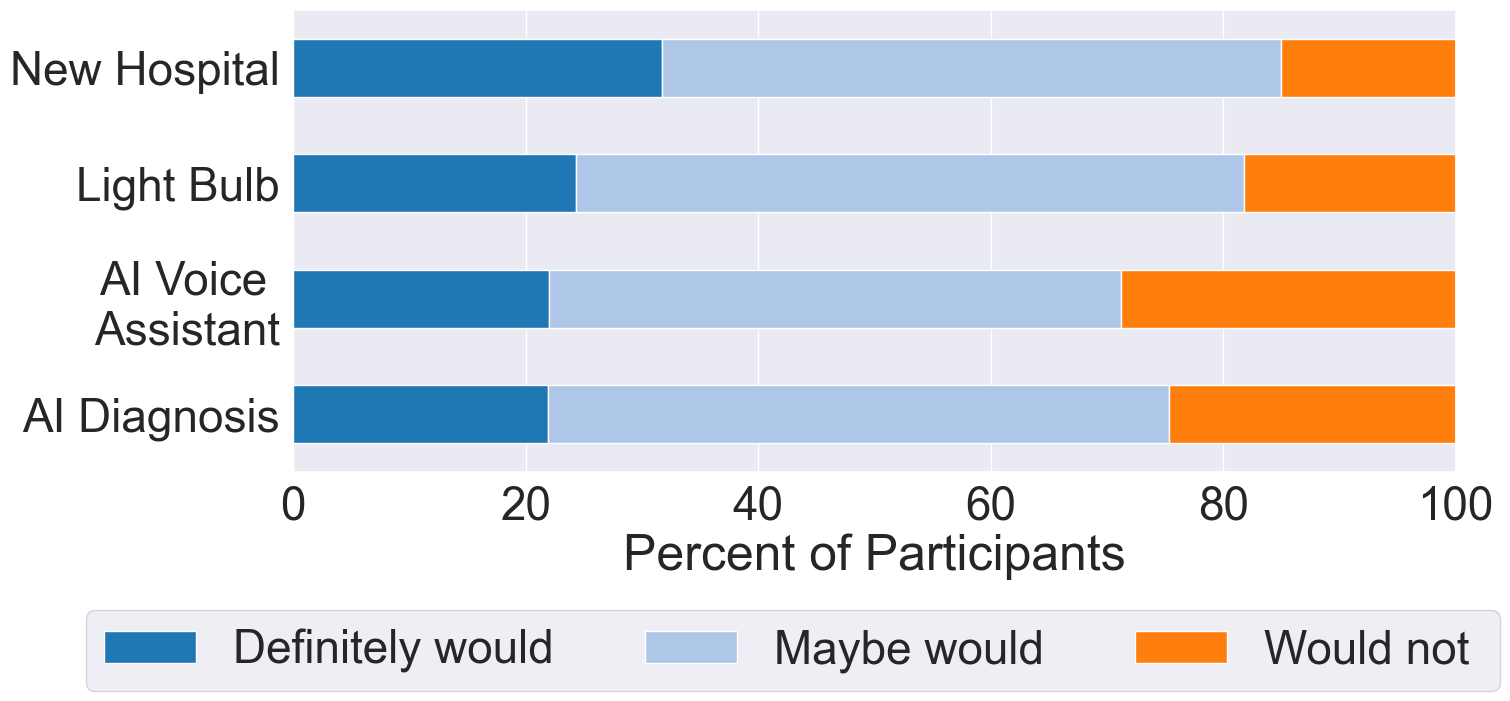

In [ ]:
med_c = medicalC_willingness_counts["willingness"]
med_s = medicalS_willingness_counts["willingness"]
iot_c = iotC_willingness_counts["willingness"]
iot_s = iotS_willingness_counts["willingness"]

all_willingness_chart = pd.DataFrame(med_c/sum(med_c) * 100).rename(
        columns={"willingness":"AI Diagnosis"}) \
    .join(pd.DataFrame(med_s/sum(med_s) * 100).rename(
        columns={"willingness":"New Hospital"})) \
    .join(pd.DataFrame(iot_c/sum(iot_c) * 100).rename(
        columns={"willingness":"AI Voice \nAssistant"})) \
    .join(pd.DataFrame(iot_s/sum(iot_s) * 100).rename(
        columns={"willingness":"Light Bulb"})) 

sns.set(font_scale=3)
sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=3)
ax = all_willingness_chart.transpose() \
    .sort_values(by=["Definitely would"]) \
    .plot(kind='barh', stacked=True, figsize=(15,6))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper center', bbox_to_anchor=(0.43, -0.25), ncols=3) 

### Per TEE Explanation Condition

In [ ]:
hw_results = overall_willingness.loc[overall_willingness["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
trust_results = overall_willingness.loc[overall_willingness["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
unsub_results = overall_willingness.loc[overall_willingness["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
none_results = overall_willingness.loc[overall_willingness["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)

hw_willingness_counts = hw_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
trust_willingness_counts = trust_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
unsub_willingness_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
none_willingness_counts = none_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)

all_willingness = pd.DataFrame(hw_willingness_counts).rename(columns={"willingness":"Hardware"}) \
    .join(pd.DataFrame(trust_willingness_counts.rename(columns={"willingness":"Trust"}))) \
    .join(pd.DataFrame(unsub_willingness_counts.rename(columns={"willingness":"Unsubstantial"}))) \
    .join(pd.DataFrame(none_willingness_counts.rename(columns={"willingness":"None"})))

all_willingness["Hardware"] = all_willingness["Hardware"] / len(hw_results)
all_willingness["Trust"] = all_willingness["Trust"] / len(trust_results)
all_willingness["Unsubstantial"] = all_willingness["Unsubstantial"] / len(unsub_results)
all_willingness["None"] = all_willingness["None"] / len(none_results)
 
all_willingness.style.format('{:.1%}')

,Hardware,Trust,Unsubstantial,None
Definitely would,27.2%,24.0%,23.6%,25.0%
Maybe would,52.8%,51.6%,54.3%,54.5%
Would not,20.0%,24.4%,22.0%,20.5%


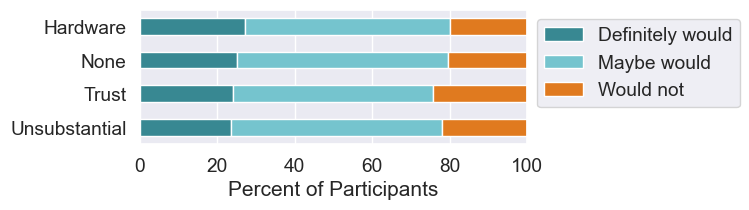

In [ ]:
hw = hw_willingness_counts["willingness"]
trust = trust_willingness_counts["willingness"]
unsub = unsub_willingness_counts["willingness"]
noexp = none_willingness_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(hw/sum(hw) * 100).rename(
        columns={"willingness":"Hardware"}) \
    .join(pd.DataFrame(trust/sum(trust) * 100).rename(
        columns={"willingness":"Trust"})) \
    .join(pd.DataFrame(unsub/sum(unsub) * 100).rename(
        columns={"willingness":"Unsubstantial"})) \
    .join(pd.DataFrame(noexp/sum(noexp) * 100).rename(
        columns={"willingness":"None"}))

sns.set(font_scale=1.25)
sns.set_palette(['#388892','#75C4CE','#E07A1F','#DAB085'], n_colors=4)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(5,1.75))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=1) 

In [ ]:
hw_results = overall_willingness.loc[overall_willingness["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
trust_results = overall_willingness.loc[overall_willingness["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
unsub_results = overall_willingness.loc[overall_willingness["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
none_results = overall_willingness.loc[overall_willingness["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)

hw_willingness_counts = hw_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
trust_willingness_counts = trust_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
unsub_willingness_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
none_willingness_counts = none_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)

expln_willingness_counts = hw_willingness_counts + trust_willingness_counts + unsub_willingness_counts

all_willingness = pd.DataFrame(expln_willingness_counts).rename(columns={"willingness":"Expln"}) \
    .join(pd.DataFrame(none_willingness_counts.rename(columns={"willingness":"None"})))

all_willingness["Expln"] = all_willingness["Expln"] / len(hw_results+trust_results+unsub_results)
all_willingness["None"] = all_willingness["None"] / len(none_results)
 
all_willingness.style.format('{:.1%}')

,Expln,None
Definitely would,24.9%,25.0%
Maybe would,52.9%,54.5%
Would not,22.1%,20.5%


### Per FAQ Condition

In [ ]:
shown_results = overall_willingness.loc[overall_willingness["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
hidden_results = overall_willingness.loc[overall_willingness["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
none_results = overall_willingness.loc[overall_willingness["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)

shown_willingness_counts = shown_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
hidden_willingness_counts = hidden_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
none_willingness_counts = none_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)

all_willingness = pd.DataFrame(shown_willingness_counts).rename(columns={"willingness":"Shown"}) \
    .join(pd.DataFrame(hidden_willingness_counts.rename(columns={"willingness":"Hidden"}))) \
    .join(pd.DataFrame(none_willingness_counts.rename(columns={"willingness":"None"})))

all_willingness["Shown"] = all_willingness["Shown"] / len(shown_results)
all_willingness["Hidden"] = all_willingness["Hidden"] / len(hidden_results)
all_willingness["None"] = all_willingness["None"] / len(none_results)
 
all_willingness.style.format('{:.1%}')

,Shown,Hidden,None
Definitely would,28.0%,23.2%,23.7%
Maybe would,52.7%,52.7%,54.5%
Would not,19.2%,24.1%,21.9%


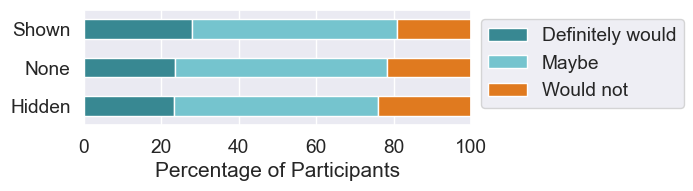

In [ ]:
show = shown_willingness_counts["willingness"]
hide = hidden_willingness_counts["willingness"]
nofaq = none_willingness_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(show/sum(show) * 100).rename(
        columns={"willingness":"Shown"}) \
    .join(pd.DataFrame(hide/sum(hide) * 100).rename(
        columns={"willingness":"Hidden"})) \
    .join(pd.DataFrame(nofaq/sum(nofaq) * 100).rename(
        columns={"willingness":"None"}))

willingnessMap = {
    "Definitely would" : "Definitely would",
    "Maybe would" : "Maybe",
    "Would not" : "Would not"
}   

treatment_willingness_chart.rename(index=willingnessMap,inplace=True)

sns.set(font_scale=1.25)
sns.set_palette(['#388892','#75C4CE','#E07A1F','#DAB085'], n_colors=3)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe"]) \
    .plot(kind='barh', stacked=True, figsize=(5,1.5))
ax.set_xlabel('Percentage of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=1) 

In [ ]:
shown_results = overall_willingness.loc[overall_willingness["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
hidden_results = overall_willingness.loc[overall_willingness["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)
none_results = overall_willingness.loc[overall_willingness["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3",],axis=1)

shown_willingness_counts = shown_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
hidden_willingness_counts = hidden_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)
none_willingness_counts = none_results.apply(lambda col: col.value_counts()).reindex(willingness_scale).fillna(0)

faq_willingness_counts = shown_willingness_counts + hidden_willingness_counts

all_willingness = pd.DataFrame(faq_willingness_counts).rename(columns={"willingness":"FAQ"}) \
    .join(pd.DataFrame(none_willingness_counts.rename(columns={"willingness":"None"})))

all_willingness["FAQ"] = all_willingness["FAQ"] / len(shown_results+hidden_results)
all_willingness["None"] = all_willingness["None"] / len(none_results)
 
all_willingness.style.format('{:.1%}')

,FAQ,None
Definitely would,25.6%,23.7%
Maybe would,52.7%,54.5%
Would not,21.7%,21.9%


### Per TEE Explanation/FAQ Condition

In [ ]:
hw_results = overall_willingness.loc[overall_willingness["Expln"] == "Hardware"] \
        .drop(["Expln", "count1", "count2", "count3",],axis=1)
trust_results = overall_willingness.loc[overall_willingness["Expln"] == "Trust"] \
        .drop(["Expln", "count1", "count2", "count3",],axis=1)
unsub_results = overall_willingness.loc[overall_willingness["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "count1", "count2", "count3",],axis=1)
none_results = overall_willingness.loc[overall_willingness["Expln"] == "None"] \
        .drop(["Expln", "count1", "count2", "count3",],axis=1)

hw_show_results = hw_results.loc[hw_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
hw_hide_results = hw_results.loc[hw_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
hw_none_results = hw_results.loc[hw_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
trust_show_results = trust_results.loc[trust_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
trust_hide_results = trust_results.loc[trust_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
trust_none_results = trust_results.loc[trust_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
unsub_show_results = unsub_results.loc[unsub_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
unsub_hide_results = unsub_results.loc[unsub_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
unsub_none_results = unsub_results.loc[unsub_results["FAQ"] == "None"].drop(["FAQ"], axis=1)
none_show_results = none_results.loc[none_results["FAQ"] == "Show"].drop(["FAQ"], axis=1)
none_hide_results = none_results.loc[none_results["FAQ"] == "Hide"].drop(["FAQ"], axis=1)
none_none_results = none_results.loc[none_results["FAQ"] == "None"].drop(["FAQ"], axis=1)

hw_show_counts = hw_show_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
hw_hide_counts = hw_hide_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
hw_none_counts = hw_none_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
trust_show_counts = trust_show_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
trust_hide_counts = trust_hide_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
trust_none_counts = trust_none_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
unsub_show_counts = unsub_show_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
unsub_hide_counts = unsub_hide_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
unsub_none_counts = unsub_none_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
none_show_counts = none_show_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
none_hide_counts = none_hide_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)
none_none_counts = none_none_results.apply(lambda col: col.value_counts()). \
    reindex(willingness_scale).fillna(0)

all_willingness = pd.DataFrame(hw_show_counts).rename(columns={"willingness":"Hardware/Show"}) \
    .join(pd.DataFrame(hw_hide_counts).rename(columns={"willingness":"Hardware/Hide"})) \
    .join(pd.DataFrame(hw_none_counts).rename(columns={"willingness":"Hardware/None"})) \
    .join(pd.DataFrame(trust_show_counts).rename(columns={"willingness":"Trust/Show"})) \
    .join(pd.DataFrame(trust_hide_counts).rename(columns={"willingness":"Trust/Hide"})) \
    .join(pd.DataFrame(trust_none_counts).rename(columns={"willingness":"Trust/None"})) \
    .join(pd.DataFrame(unsub_show_counts).rename(columns={"willingness":"Unsubstantial/Show"})) \
    .join(pd.DataFrame(unsub_hide_counts).rename(columns={"willingness":"Unsubstantial/Hide"})) \
    .join(pd.DataFrame(unsub_none_counts).rename(columns={"willingness":"Unsubstantial/None"})) \
    .join(pd.DataFrame(none_show_counts).rename(columns={"willingness":"None/Show"})) \
    .join(pd.DataFrame(none_hide_counts).rename(columns={"willingness":"None/Hide"})) \
    .join(pd.DataFrame(none_none_counts).rename(columns={"willingness":"None/None"}))

all_willingness["Hardware/Show"] = all_willingness["Hardware/Show"] / len(hw_show_results)
all_willingness["Hardware/Hide"] = all_willingness["Hardware/Hide"] / len(hw_hide_results)
all_willingness["Hardware/None"] = all_willingness["Hardware/None"] / len(hw_none_results)
all_willingness["Trust/Show"] = all_willingness["Trust/Show"] / len(trust_show_results)
all_willingness["Trust/Hide"] = all_willingness["Trust/Hide"] / len(trust_hide_results)
all_willingness["Trust/None"] = all_willingness["Trust/None"] / len(trust_none_results)
all_willingness["Unsubstantial/Show"] = all_willingness["Unsubstantial/Show"] / len(unsub_show_results)
all_willingness["Unsubstantial/Hide"] = all_willingness["Unsubstantial/Hide"] / len(unsub_hide_results)
all_willingness["Unsubstantial/None"] = all_willingness["Unsubstantial/None"] / len(unsub_none_results)
all_willingness["None/Show"] = all_willingness["None/Show"] / len(none_show_results)
all_willingness["None/Hide"] = all_willingness["None/Hide"] / len(none_hide_results)
all_willingness["None/None"] = all_willingness["None/None"] / len(none_none_results)
 
all_willingness.style.format('{:.1%}')

,Hardware/Show,Hardware/Hide,Hardware/None,Trust/Show,Trust/Hide,Trust/None,Unsubstantial/Show,Unsubstantial/Hide,Unsubstantial/None,None/Show,None/Hide,None/None
Definitely would,20.8%,31.5%,27.1%,26.1%,23.0%,22.5%,37.5%,8.8%,24.5%,27.4%,27.1%,21.1%
Maybe would,56.9%,45.4%,60.0%,51.1%,54.1%,50.0%,48.8%,58.8%,55.3%,54.8%,55.7%,53.3%
Would not,22.2%,23.1%,12.9%,22.8%,23.0%,27.5%,13.8%,32.5%,20.2%,17.9%,17.1%,25.6%


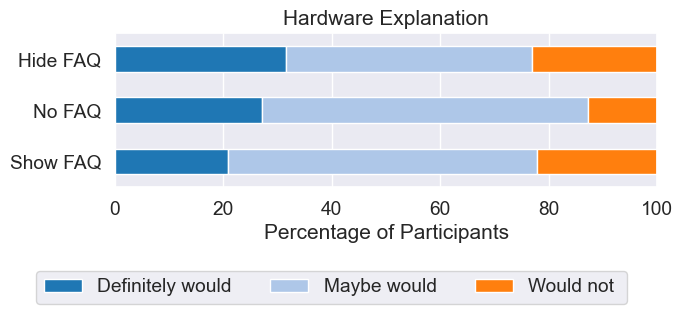

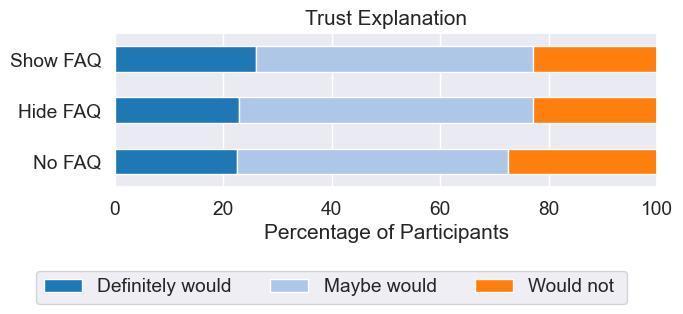

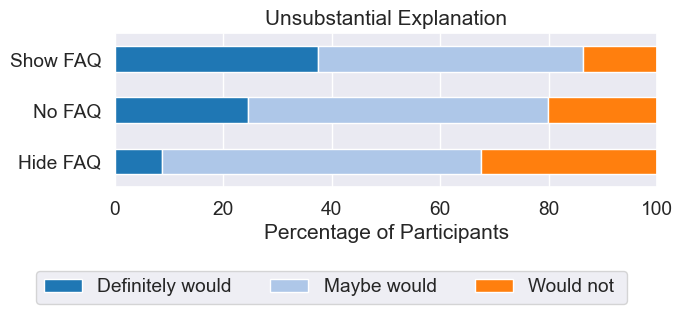

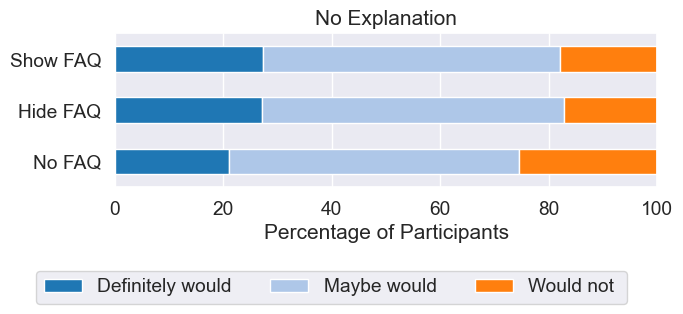

In [ ]:
hw_show = hw_show_counts["willingness"]
hw_hidden = hw_hide_counts["willingness"]
hw_none = hw_none_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(hw_show/sum(hw_show) * 100).rename(
        columns={"willingness":"Show FAQ"}) \
    .join(pd.DataFrame(hw_hidden/sum(hw_hidden) * 100).rename(
        columns={"willingness":"Hide FAQ"})) \
    .join(pd.DataFrame(hw_none/sum(hw_none) * 100).rename(
        columns={"willingness":"No FAQ"}))

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=3)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(7,2))
ax.set_title('Hardware Explanation')
ax.set_xlabel('Percentage of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.82), frameon=True, ncol=3) 

#########################################

trust_show = trust_show_counts["willingness"]
trust_hidden = trust_hide_counts["willingness"]
trust_none = trust_none_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(trust_show/sum(trust_show) * 100).rename(
        columns={"willingness":"Show FAQ"}) \
    .join(pd.DataFrame(trust_hidden/sum(trust_hidden) * 100).rename(
        columns={"willingness":"Hide FAQ"})) \
    .join(pd.DataFrame(trust_none/sum(trust_none) * 100).rename(
        columns={"willingness":"No FAQ"}))

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=3)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(7,2))
ax.set_title('Trust Explanation')
ax.set_xlabel('Percentage of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.82), frameon=True, ncol=3) 

#########################################

unsub_show = unsub_show_counts["willingness"]
unsub_hidden = unsub_hide_counts["willingness"]
unsub_none = unsub_none_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(unsub_show/sum(unsub_show) * 100).rename(
        columns={"willingness":"Show FAQ"}) \
    .join(pd.DataFrame(unsub_hidden/sum(unsub_hidden) * 100).rename(
        columns={"willingness":"Hide FAQ"})) \
    .join(pd.DataFrame(unsub_none/sum(unsub_none) * 100).rename(
        columns={"willingness":"No FAQ"}))

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=3)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(7,2))
ax.set_title('Unsubstantial Explanation')
ax.set_xlabel('Percentage of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.82), frameon=True, ncol=3) 

#########################################

none_show = none_show_counts["willingness"]
none_hidden = none_hide_counts["willingness"]
none_none = none_none_counts["willingness"]

treatment_willingness_chart = pd.DataFrame(none_show/sum(none_show) * 100).rename(
        columns={"willingness":"Show FAQ"}) \
    .join(pd.DataFrame(none_hidden/sum(none_hidden) * 100).rename(
        columns={"willingness":"Hide FAQ"})) \
    .join(pd.DataFrame(none_none/sum(none_none) * 100).rename(
        columns={"willingness":"No FAQ"}))

sns.set_palette(['#1F77B4','#AEC7E8','#FF7F0E','#FFBB78'], n_colors=3)
ax = treatment_willingness_chart.transpose() \
    .sort_values(by=["Definitely would", "Maybe would"]) \
    .plot(kind='barh', stacked=True, figsize=(7,2))
ax.set_title('No Explanation')
ax.set_xlabel('Percentage of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.4, -0.82), frameon=True, ncol=3) 

## Overall Perception of Safety

In [ ]:
medical_safety_results = results[["SCENARIO_Med", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count",
                                  "safety-medical-overall-init","safety-medical-overall-post"]]
medical_safety_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "safety (init)", "safety (post)"]

iot_safety_results = results[["SCENARIO_IoT", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count",
                              "safety-iot-overall-init","safety-iot-overall-post"]]
iot_safety_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "safety (init)", "safety (post)"]

overall_safety = pd.concat([medical_safety_results.drop(["Scenario"],axis=1),
                        iot_safety_results.drop(["Scenario"],axis=1)],axis=0)

safety_scale = ["Completely safe","Mostly safe","Somewhat safe","Not at all safe"]

### Per Scenario

In [ ]:
medicalC_results = medical_safety_results.loc[medical_safety_results["Scenario"] == "Medical-Complex"] \
    .drop(["Scenario","Expln", "FAQ", "count1", "count2", "count3"],axis=1)
medicalS_results = medical_safety_results.loc[medical_safety_results["Scenario"] == "Medical-Simple"] \
    .drop(["Scenario","Expln", "FAQ", "count1", "count2", "count3"],axis=1)
iotC_results = iot_safety_results.loc[iot_safety_results["Scenario"] == "IoT-Complex"] \
    .drop(["Scenario","Expln", "FAQ", "count1", "count2", "count3"],axis=1)
iotS_results = iot_safety_results.loc[iot_safety_results["Scenario"] == "IoT-Simple"] \
    .drop(["Scenario","Expln", "FAQ", "count1", "count2", "count3"],axis=1)

medicalC_safety_counts = medicalC_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
medicalS_safety_counts = medicalS_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
iotC_safety_counts = iotC_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
iotS_safety_counts = iotS_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

medicalC_safety_counts["safety (delta)"] = medicalC_safety_counts["safety (post)"] - medicalC_safety_counts["safety (init)"]
medicalS_safety_counts["safety (delta)"] = medicalS_safety_counts["safety (post)"] - medicalS_safety_counts["safety (init)"]
iotC_safety_counts["safety (delta)"] = iotC_safety_counts["safety (post)"] - iotC_safety_counts["safety (init)"]
iotS_safety_counts["safety (delta)"] = iotS_safety_counts["safety (post)"] - iotS_safety_counts["safety (init)"]

all_safety = pd.DataFrame(medicalC_safety_counts).rename(
        columns={"safety (init)":"Medical Complex (init)", "safety (post)":"Medical Complex (post)", "safety (delta)":"Medical Complex (delta)"}) \
    .join(pd.DataFrame(medicalS_safety_counts.rename(
        columns={"safety (init)":"Medical Simple (init)", "safety (post)":"Medical Simple (post)", "safety (delta)":"Medical Simple (delta)"}))) \
    .join(pd.DataFrame(iotC_safety_counts.rename(
        columns={"safety (init)":"IoT Complex (init)", "safety (post)":"IoT Complex (post)", "safety (delta)":"IoT Complex (delta)"}))) \
    .join(pd.DataFrame(iotS_safety_counts.rename(
        columns={"safety (init)":"IoT Simple (init)", "safety (post)":"IoT Simple (post)", "safety (delta)":"IoT Simple (delta)"}))) 

all_safety["Medical Complex (init)"] = all_safety["Medical Complex (init)"] / len(medicalC_results)
all_safety["Medical Simple (init)"] = all_safety["Medical Simple (init)"] / len(medicalS_results)
all_safety["IoT Complex (init)"] = all_safety["IoT Complex (init)"] / len(iotC_results)
all_safety["IoT Simple (init)"] = all_safety["IoT Simple (init)"] / len(iotS_results)
all_safety["Medical Complex (post)"] = all_safety["Medical Complex (post)"] / len(medicalC_results)
all_safety["Medical Simple (post)"] = all_safety["Medical Simple (post)"] / len(medicalS_results)
all_safety["IoT Complex (post)"] = all_safety["IoT Complex (post)"] / len(iotC_results)
all_safety["IoT Simple (post)"] = all_safety["IoT Simple (post)"] / len(iotS_results)
all_safety["Medical Complex (delta)"] = all_safety["Medical Complex (delta)"] / len(medicalC_results)
all_safety["Medical Simple (delta)"] = all_safety["Medical Simple (delta)"] / len(medicalS_results)
all_safety["IoT Complex (delta)"] = all_safety["IoT Complex (delta)"] / len(iotC_results)
all_safety["IoT Simple (delta)"] = all_safety["IoT Simple (delta)"] / len(iotS_results)

all_safety.style.format('{:.1%}')

,Medical Complex (init),Medical Complex (post),Medical Complex (delta),Medical Simple (init),Medical Simple (post),Medical Simple (delta),IoT Complex (init),IoT Complex (post),IoT Complex (delta),IoT Simple (init),IoT Simple (post),IoT Simple (delta)
Completely safe,16.7%,10.4%,-6.4%,18.3%,15.9%,-2.4%,14.0%,9.6%,-4.4%,17.0%,13.8%,-3.2%
Mostly safe,51.0%,55.0%,4.0%,54.5%,58.9%,4.5%,52.0%,54.8%,2.8%,57.1%,56.3%,-0.8%
Somewhat safe,24.7%,29.1%,4.4%,23.6%,21.1%,-2.4%,28.0%,30.8%,2.8%,24.3%,26.3%,2.0%
Not at all safe,7.6%,5.6%,-2.0%,3.7%,4.1%,0.4%,6.0%,4.8%,-1.2%,1.6%,3.6%,2.0%


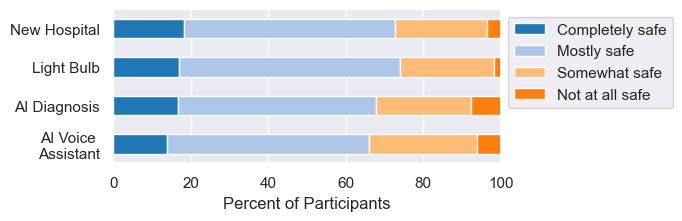

In [ ]:
med_c = medicalC_safety_counts["safety (init)"]
med_s = medicalS_safety_counts["safety (init)"]
iot_c = iotC_safety_counts["safety (init)"]
iot_s = iotS_safety_counts["safety (init)"]

all_safety_chart = pd.DataFrame(med_c/sum(med_c) * 100).rename(
        columns={"safety (init)":"AI Diagnosis"}) \
    .join(pd.DataFrame(med_s/sum(med_s) * 100).rename(
        columns={"safety (init)":"New Hospital"})) \
    .join(pd.DataFrame(iot_c/sum(iot_c) * 100).rename(
        columns={"safety (init)":"AI Voice \nAssistant"})) \
    .join(pd.DataFrame(iot_s/sum(iot_s) * 100).rename(
        columns={"safety (init)":"Light Bulb"})) 

sns.set(font_scale=1)
sns.set_palette(['#1F77B4','#AEC7E8','#FFBB78','#FF7F0E'], n_colors=4)
ax = all_safety_chart.transpose() \
    .sort_values(by=["Completely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(5,2))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1,1)) 

### Per TEE Explanation Condition

In [ ]:
hw_results = overall_safety.loc[overall_safety["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_results = overall_safety.loc[overall_safety["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_results = overall_safety.loc[overall_safety["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_results = overall_safety.loc[overall_safety["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

hw_safety_counts = hw_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_safety_counts = trust_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_safety_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_safety_counts = none_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

hw_safety_counts["safety (delta)"] = hw_safety_counts["safety (post)"] - hw_safety_counts["safety (init)"]
trust_safety_counts["safety (delta)"] = trust_safety_counts["safety (post)"] - trust_safety_counts["safety (init)"]
unsub_safety_counts["safety (delta)"] = unsub_safety_counts["safety (post)"] - unsub_safety_counts["safety (init)"]
none_safety_counts["safety (delta)"] = none_safety_counts["safety (post)"] - none_safety_counts["safety (init)"]

all_safety = pd.DataFrame(hw_safety_counts).rename(columns={
        "safety (init)":"Hardware (init)", "safety (post)":"Hardware (post)", "safety (delta)":"Hardware (delta)"}) \
    .join(pd.DataFrame(trust_safety_counts.rename(columns={
        "safety (init)":"Trust (init)", "safety (post)":"Trust (post)", "safety (delta)":"Trust (delta)"}))) \
    .join(pd.DataFrame(unsub_safety_counts.rename(columns={
        "safety (init)":"Unsubstantial (init)", "safety (post)":"Unsubstantial (post)", "safety (delta)":"Unsubstantial (delta)"}))) \
    .join(pd.DataFrame(none_safety_counts.rename(columns={
        "safety (init)":"None (init)", "safety (post)":"None (post)", "safety (delta)":"None (delta)"})))

all_safety["Hardware (init)"] = all_safety["Hardware (init)"] / len(hw_results)
all_safety["Trust (init)"] = all_safety["Trust (init)"] / len(trust_results)
all_safety["Unsubstantial (init)"] = all_safety["Unsubstantial (init)"] / len(unsub_results)
all_safety["None (init)"] = all_safety["None (init)"] / len(none_results)
all_safety["Hardware (post)"] = all_safety["Hardware (post)"] / len(hw_results)
all_safety["Trust (post)"] = all_safety["Trust (post)"] / len(trust_results)
all_safety["Unsubstantial (post)"] = all_safety["Unsubstantial (post)"] / len(unsub_results)
all_safety["None (post)"] = all_safety["None (post)"] / len(none_results)
all_safety["Hardware (delta)"] = all_safety["Hardware (delta)"] / len(hw_results)
all_safety["Trust (delta)"] = all_safety["Trust (delta)"] / len(trust_results)
all_safety["Unsubstantial (delta)"] = all_safety["Unsubstantial (delta)"] / len(unsub_results)
all_safety["None (delta)"] = all_safety["None (delta)"] / len(none_results)
 
all_safety.style.format('{:.1%}')

,Hardware (init),Hardware (post),Hardware (delta),Trust (init),Trust (post),Trust (delta),Unsubstantial (init),Unsubstantial (post),Unsubstantial (delta),None (init),None (post),None (delta)
Completely safe,18.8%,16.4%,-2.4%,16.7%,14.2%,-2.4%,15.7%,9.4%,-6.3%,14.8%,9.4%,-5.3%
Mostly safe,55.2%,57.6%,2.4%,56.5%,56.5%,0.0%,54.3%,59.1%,4.7%,48.4%,51.6%,3.3%
Somewhat safe,20.8%,20.8%,0.0%,22.8%,26.0%,3.3%,26.4%,29.1%,2.8%,30.7%,31.6%,0.8%
Not at all safe,5.2%,5.2%,0.0%,4.1%,3.3%,-0.8%,3.5%,2.4%,-1.2%,6.1%,7.4%,1.2%


In [ ]:
hw_results = overall_safety.loc[overall_safety["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_results = overall_safety.loc[overall_safety["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_results = overall_safety.loc[overall_safety["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_results = overall_safety.loc[overall_safety["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

hw_safety_counts = hw_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_safety_counts = trust_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_safety_counts = unsub_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_safety_counts = none_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

expln_safety_coutns = hw_safety_counts + trust_safety_counts + unsub_safety_counts

expln_safety_coutns["safety (delta)"] = expln_safety_coutns["safety (post)"] - expln_safety_coutns["safety (init)"]
none_safety_counts["safety (delta)"] = none_safety_counts["safety (post)"] - none_safety_counts["safety (init)"]

all_safety = pd.DataFrame(expln_safety_coutns).rename(columns={
        "safety (init)":"Expln (init)", "safety (post)":"Expln (post)", "safety (delta)":"Expln (delta)"}) \
    .join(pd.DataFrame(none_safety_counts).rename(columns={
        "safety (init)":"None (init)", "safety (post)":"None (post)", "safety (delta)":"None (delta)"}))

all_safety["Expln (init)"] = all_safety["Expln (init)"] / len(hw_results+trust_results+unsub_results)
all_safety["None (init)"] = all_safety["None (init)"] / len(none_results)
all_safety["Expln (post)"] = all_safety["Expln (post)"] / len(hw_results+trust_results+unsub_results)
all_safety["None (post)"] = all_safety["None (post)"] / len(none_results)
all_safety["Expln (delta)"] = all_safety["Expln (delta)"] / len(hw_results+trust_results+unsub_results)
all_safety["None (delta)"] = all_safety["None (delta)"] / len(none_results)
 
all_safety.style.format('{:.1%}')

,Expln (init),Expln (post),Expln (delta),None (init),None (post),None (delta)
Completely safe,17.1%,13.3%,-3.7%,14.8%,9.4%,-5.3%
Mostly safe,55.3%,57.7%,2.4%,48.4%,51.6%,3.3%
Somewhat safe,23.3%,25.3%,2.0%,30.7%,31.6%,0.8%
Not at all safe,4.3%,3.6%,-0.7%,6.1%,7.4%,1.2%


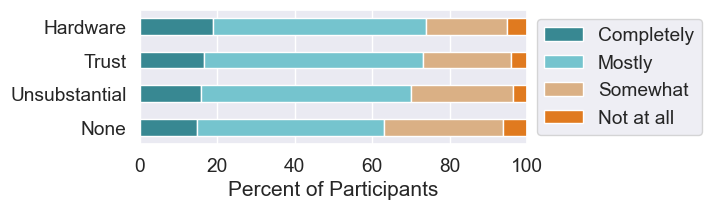

In [ ]:
hw = hw_safety_counts["safety (init)"]
trust = trust_safety_counts["safety (init)"]
unsub = unsub_safety_counts["safety (init)"]
noexp = none_safety_counts["safety (init)"]

treatment_safety_chart = pd.DataFrame(hw/sum(hw) * 100).rename(
        columns={"safety (init)":"Hardware"}) \
    .join(pd.DataFrame(trust/sum(trust) * 100).rename(
        columns={"safety (init)":"Trust"})) \
    .join(pd.DataFrame(unsub/sum(unsub) * 100).rename(
        columns={"safety (init)":"Unsubstantial"})) \
    .join(pd.DataFrame(noexp/sum(noexp) * 100).rename(
        columns={"safety (init)":"None"})) 

safetyMap = {
    "Completely safe" : "Completely",
    "Mostly safe" : "Mostly",
    "Somewhat safe" : "Somewhat",
    "Not at all safe" : "Not at all"
}   

treatment_safety_chart.rename(index=safetyMap,inplace=True)

sns.set(font_scale=1.25)
sns.set_palette(['#388892','#75C4CE','#DAB085','#E07A1F'], n_colors=4)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Completely", "Somewhat"]) \
    .plot(kind='barh', stacked=True, figsize=(5,1.75))
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=1) 

### Per FAQ Condition

In [ ]:
show_results = overall_safety.loc[overall_safety["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hide_results = overall_safety.loc[overall_safety["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_results = overall_safety.loc[overall_safety["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

show_safety_counts = show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hide_safety_counts = hide_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_safety_counts = none_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

show_safety_counts["safety (delta)"] = show_safety_counts["safety (post)"] - show_safety_counts["safety (init)"]
hide_safety_counts["safety (delta)"] = hide_safety_counts["safety (post)"] - hide_safety_counts["safety (init)"]
none_safety_counts["safety (delta)"] = none_safety_counts["safety (post)"] - none_safety_counts["safety (init)"]

all_safety = pd.DataFrame(show_safety_counts).rename(columns={
        "safety (init)":"Shown (init)", "safety (post)":"Shown (post)", "safety (delta)":"Shown (delta)"}) \
    .join(pd.DataFrame(hide_safety_counts.rename(columns={
        "safety (init)":"Hidden (init)", "safety (post)":"Hidden (post)", "safety (delta)":"Hidden (delta)"}))) \
    .join(pd.DataFrame(none_safety_counts.rename(columns={
        "safety (init)":"None (init)", "safety (post)":"None (post)", "safety (delta)":"None (delta)"})))

all_safety["Shown (init)"] = all_safety["Shown (init)"] / len(show_results)
all_safety["Hidden (init)"] = all_safety["Hidden (init)"] / len(hide_results)
all_safety["None (init)"] = all_safety["None (init)"] / len(none_results)
all_safety["Shown (post)"] = all_safety["Shown (post)"] / len(show_results)
all_safety["Hidden (post)"] = all_safety["Hidden (post)"] / len(hide_results)
all_safety["None (post)"] = all_safety["None (post)"] / len(none_results)
all_safety["Shown (delta)"] = all_safety["Shown (delta)"] / len(show_results)
all_safety["Hidden (delta)"] = all_safety["Hidden (delta)"] / len(hide_results)
all_safety["None (delta)"] = all_safety["None (delta)"] / len(none_results)
 
all_safety.style.format('{:.1%}')

,Shown (init),Shown (post),Shown (delta),Hidden (init),Hidden (post),Hidden (delta),None (init),None (post),None (delta)
Completely safe,21.0%,14.0%,-7.0%,16.3%,14.8%,-1.5%,12.3%,8.4%,-3.9%
Mostly safe,54.0%,60.1%,6.1%,55.1%,55.7%,0.6%,51.8%,53.0%,1.2%
Somewhat safe,21.6%,22.9%,1.2%,24.7%,25.6%,0.9%,29.0%,32.0%,3.0%
Not at all safe,3.4%,3.0%,-0.3%,3.9%,3.9%,0.0%,6.9%,6.6%,-0.3%


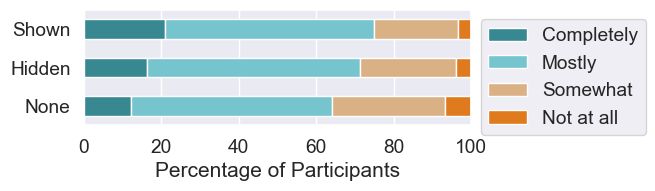

In [ ]:
show = show_safety_counts["safety (init)"]
hide = hide_safety_counts["safety (init)"]
nofaq = none_safety_counts["safety (init)"]

treatment_safety_chart = pd.DataFrame(show/sum(show) * 100).rename(
        columns={"safety (init)":"Shown"}) \
    .join(pd.DataFrame(hide/sum(hide) * 100).rename(
        columns={"safety (init)":"Hidden"})) \
    .join(pd.DataFrame(nofaq/sum(nofaq) * 100).rename(
        columns={"safety (init)":"None"}))

safetyMap = {
    "Completely safe" : "Completely",
    "Mostly safe" : "Mostly",
    "Somewhat safe" : "Somewhat",
    "Not at all safe" : "Not at all"
}   

treatment_safety_chart.rename(index=safetyMap,inplace=True)

sns.set(font_scale=1.25)
sns.set_palette(['#388892','#75C4CE','#DAB085','#E07A1F'], n_colors=4)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Completely", "Somewhat"]) \
    .plot(kind='barh', stacked=True, figsize=(5,1.5))
ax.set_xlabel('Percentage of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), ncols=1) 

In [ ]:
show_results = overall_safety.loc[overall_safety["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hide_results = overall_safety.loc[overall_safety["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_results = overall_safety.loc[overall_safety["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

show_safety_counts = show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hide_safety_counts = hide_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_safety_counts = none_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

faq_safety_counts = show_safety_counts + hide_safety_counts

faq_safety_counts["safety (delta)"] = faq_safety_counts["safety (post)"] - faq_safety_counts["safety (init)"]
none_safety_counts["safety (delta)"] = none_safety_counts["safety (post)"] - none_safety_counts["safety (init)"]

all_safety = pd.DataFrame(faq_safety_counts).rename(columns={
        "safety (init)":"FAQ (init)", "safety (post)":"FAQ (post)", "safety (delta)":"FAQ (delta)"}) \
    .join(pd.DataFrame(none_safety_counts.rename(columns={
        "safety (init)":"None (init)", "safety (post)":"None (post)", "safety (delta)":"None (delta)"})))

all_safety["FAQ (init)"] = all_safety["FAQ (init)"] / len(show_results+hide_results)
all_safety["None (init)"] = all_safety["None (init)"] / len(none_results)
all_safety["FAQ (post)"] = all_safety["FAQ (post)"] / len(show_results+hide_results)
all_safety["None (post)"] = all_safety["None (post)"] / len(none_results)
all_safety["FAQ (delta)"] = all_safety["FAQ (delta)"] / len(show_results+hide_results)
all_safety["None (delta)"] = all_safety["None (delta)"] / len(none_results)
 
all_safety.style.format('{:.1%}')

,FAQ (init),FAQ (post),FAQ (delta),None (init),None (post),None (delta)
Completely safe,18.6%,14.4%,-4.2%,12.3%,8.4%,-3.9%
Mostly safe,54.5%,57.9%,3.3%,51.8%,53.0%,1.2%
Somewhat safe,23.2%,24.2%,1.1%,29.0%,32.0%,3.0%
Not at all safe,3.6%,3.5%,-0.2%,6.9%,6.6%,-0.3%


### Per TEE Explanation/FAQ Condition

In [ ]:
hw_results = overall_safety.loc[overall_safety["Expln"] == "Hardware"] \
        .drop(["Expln", "count1", "count2", "count3", "safety (post)"],axis=1)
trust_results = overall_safety.loc[overall_safety["Expln"] == "Trust"] \
        .drop(["Expln", "count1", "count2", "count3", "safety (post)"],axis=1)
unsub_results = overall_safety.loc[overall_safety["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "count1", "count2", "count3", "safety (post)"],axis=1)
none_results = overall_safety.loc[overall_safety["Expln"] == "None"] \
        .drop(["Expln", "count1", "count2", "count3", "safety (post)"],axis=1)

hw_show_results = hw_results.loc[hw_results["FAQ"] == "Show"].drop(["FAQ"],axis=1)
hw_hide_results = hw_results.loc[hw_results["FAQ"] == "Hide"].drop(["FAQ"],axis=1)
hw_none_results = hw_results.loc[hw_results["FAQ"] == "None"].drop(["FAQ"],axis=1)
trust_show_results = trust_results.loc[trust_results["FAQ"] == "Show"].drop(["FAQ"],axis=1)
trust_hide_results = trust_results.loc[trust_results["FAQ"] == "Hide"].drop(["FAQ"],axis=1)
trust_none_results = trust_results.loc[trust_results["FAQ"] == "None"].drop(["FAQ"],axis=1)
unsub_show_results = unsub_results.loc[unsub_results["FAQ"] == "Show"].drop(["FAQ"],axis=1)
unsub_hide_results = unsub_results.loc[unsub_results["FAQ"] == "Hide"].drop(["FAQ"],axis=1)
unsub_none_results = unsub_results.loc[unsub_results["FAQ"] == "None"].drop(["FAQ"],axis=1)
none_show_results = none_results.loc[none_results["FAQ"] == "Show"].drop(["FAQ"],axis=1)
none_hide_results = none_results.loc[none_results["FAQ"] == "Hide"].drop(["FAQ"],axis=1)
none_none_results = none_results.loc[none_results["FAQ"] == "None"].drop(["FAQ"],axis=1)

hw_show_counts = hw_show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_hide_counts = hw_hide_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_none_counts = hw_none_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_show_counts = trust_show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_hide_counts = trust_hide_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_none_counts = trust_none_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_show_counts = unsub_show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_hide_counts = unsub_hide_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_none_counts = unsub_none_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_show_counts = none_show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_hide_counts = none_hide_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_none_counts = none_none_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(hw_show_counts).rename(columns={"safety (init)":"Hardware/Show"}) \
    .join(pd.DataFrame(trust_show_counts.rename(columns={"safety (init)":"Trust/Show"}))) \
    .join(pd.DataFrame(unsub_show_counts.rename(columns={"safety (init)":"Unsubstantial/Show"}))) \
    .join(pd.DataFrame(none_show_counts.rename(columns={"safety (init)":"None/Show"}))) \
    .join(pd.DataFrame(hw_hide_counts).rename(columns={"safety (init)":"Hardware/Hide"})) \
    .join(pd.DataFrame(trust_hide_counts.rename(columns={"safety (init)":"Trust/Hide"}))) \
    .join(pd.DataFrame(unsub_hide_counts.rename(columns={"safety (init)":"Unsubstantial/Hide"}))) \
    .join(pd.DataFrame(none_hide_counts.rename(columns={"safety (init)":"None/Hide"}))) \
    .join(pd.DataFrame(hw_none_counts).rename(columns={"safety (init)":"Hardware/None"})) \
    .join(pd.DataFrame(trust_none_counts.rename(columns={"safety (init)":"Trust/None"}))) \
    .join(pd.DataFrame(unsub_none_counts.rename(columns={"safety (init)":"Unsubstantial/None"}))) \
    .join(pd.DataFrame(none_none_counts.rename(columns={"safety (init)":"None/None"}))) 

all_safety["Hardware/Show"] = all_safety["Hardware/Show"] / len(hw_show_results)
all_safety["Trust/Show"] = all_safety["Trust/Show"] / len(trust_show_results)
all_safety["Unsubstantial/Show"] = all_safety["Unsubstantial/Show"] / len(unsub_show_results)
all_safety["None/Show"] = all_safety["None/Show"] / len(none_show_results)
all_safety["Hardware/Hide"] = all_safety["Hardware/Hide"] / len(hw_hide_results)
all_safety["Trust/Hide"] = all_safety["Trust/Hide"] / len(trust_hide_results)
all_safety["Unsubstantial/Hide"] = all_safety["Unsubstantial/Hide"] / len(unsub_hide_results)
all_safety["None/Hide"] = all_safety["None/Hide"] / len(none_hide_results)
all_safety["Hardware/None"] = all_safety["Hardware/None"] / len(hw_none_results)
all_safety["Trust/None"] = all_safety["Trust/None"] / len(trust_none_results)
all_safety["Unsubstantial/None"] = all_safety["Unsubstantial/None"] / len(unsub_none_results)
all_safety["None/None"] = all_safety["None/None"] / len(none_none_results)
 
all_safety.style.format('{:.1%}')

,Hardware/Show,Trust/Show,Unsubstantial/Show,None/Show,Hardware/Hide,Trust/Hide,Unsubstantial/Hide,None/Hide,Hardware/None,Trust/None,Unsubstantial/None,None/None
Completely safe,18.1%,16.3%,22.5%,27.4%,22.2%,21.6%,7.5%,11.4%,14.3%,12.5%,17.0%,5.6%
Mostly safe,56.9%,51.1%,57.5%,51.2%,53.7%,54.1%,55.0%,58.6%,55.7%,65.0%,51.1%,37.8%
Somewhat safe,22.2%,28.3%,16.2%,19.0%,17.6%,21.6%,32.5%,30.0%,24.3%,17.5%,29.8%,42.2%
Not at all safe,2.8%,4.3%,3.8%,2.4%,6.5%,2.7%,5.0%,0.0%,5.7%,5.0%,2.1%,14.4%


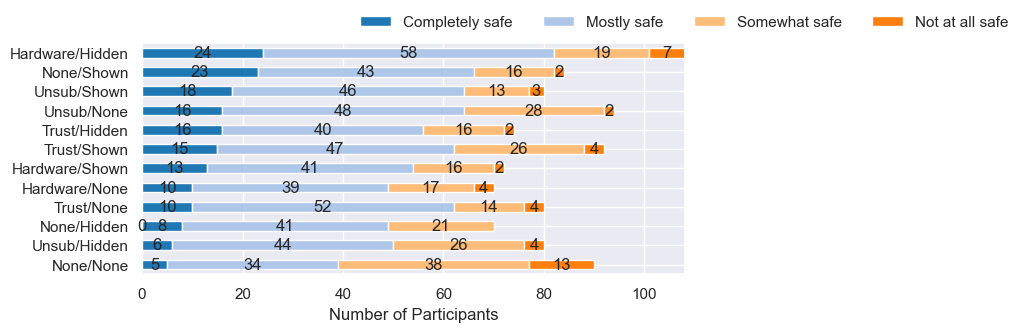

In [ ]:
treatment_safety_chart = pd.DataFrame(hw_show_counts["safety (init)"]).rename(
        columns={"safety (init)":"Hardware/Shown"}) \
    .join(pd.DataFrame(hw_hide_counts["safety (init)"]).rename(
        columns={"safety (init)":"Hardware/Hidden"})) \
    .join(pd.DataFrame(hw_none_counts["safety (init)"]).rename(
        columns={"safety (init)":"Hardware/None"})) \
    .join(pd.DataFrame(trust_show_counts["safety (init)"]).rename(
        columns={"safety (init)":"Trust/Shown"})) \
    .join(pd.DataFrame(trust_hide_counts["safety (init)"]).rename(
        columns={"safety (init)":"Trust/Hidden"})) \
    .join(pd.DataFrame(trust_none_counts["safety (init)"]).rename(
        columns={"safety (init)":"Trust/None"})) \
    .join(pd.DataFrame(unsub_show_counts["safety (init)"]).rename(
        columns={"safety (init)":"Unsub/Shown"})) \
    .join(pd.DataFrame(unsub_hide_counts["safety (init)"]).rename(
        columns={"safety (init)":"Unsub/Hidden"})) \
    .join(pd.DataFrame(unsub_none_counts["safety (init)"]).rename(
        columns={"safety (init)":"Unsub/None"})) \
    .join(pd.DataFrame(none_show_counts["safety (init)"]).rename(
        columns={"safety (init)":"None/Shown"})) \
    .join(pd.DataFrame(none_hide_counts["safety (init)"]).rename(
        columns={"safety (init)":"None/Hidden"})) \
    .join(pd.DataFrame(none_none_counts["safety (init)"]).rename(
        columns={"safety (init)":"None/None"})) 

sns.set(font_scale=1)
sns.set_palette(['#1F77B4','#AEC7E8','#FFBB78','#FF7F0E'], n_colors=4)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Completely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
ax.set_xlabel('Number of Participants')
ax.set_xlim(0,max(
    [len(hw_show_results),len(hw_hide_results),len(hw_none_results)]))
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, 1), frameon=False, ncol = 4) 

## Aspects of Scenario Contributing to Feelings of Safety

In [ ]:
medical_trust_tee_results = results[["SCENARIO_Med", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-medical-tee"]]
medical_trust_tee_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (tee)"]
medical_trust_hospital_results = results[["SCENARIO_Med", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-medical-hospital"]]
medical_trust_hospital_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (dest)"]
medical_trust_people_results = results[["SCENARIO_Med", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-medical-people"]]
medical_trust_people_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (people)"]
medical_trust_data_results = results[["SCENARIO_Med", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-medical-data"]]
medical_trust_data_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (data)"]
medical_trust_purpose_results = results[["SCENARIO_Med", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-medical-purpose"]]
medical_trust_purpose_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (purpose)"]

iot_trust_tee_results = results[["SCENARIO_IoT", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-iot-tee"]]
iot_trust_tee_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (tee)"]
iot_trust_company_results = results[["SCENARIO_IoT", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-iot-company"]]
iot_trust_company_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (dest)"]
iot_trust_people_results = results[["SCENARIO_IoT", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-iot-people"]]
iot_trust_people_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (people)"]
iot_trust_data_results = results[["SCENARIO_IoT", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-iot-data"]]
iot_trust_data_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (data)"]
iot_trust_purpose_results = results[["SCENARIO_IoT", "EXPLN", "FAQ", "faq1_count", "faq2_count", "faq3_count", "safety-iot-purpose"]]
iot_trust_purpose_results.columns = ["Scenario","Expln", "FAQ", "count1", "count2", "count3", "trust (purpose)"]

overall_trust_tee = pd.concat([medical_trust_tee_results.drop(["Scenario"],axis=1),
                        iot_trust_tee_results.drop(["Scenario"],axis=1)],axis=0)
overall_trust_dest = pd.concat([medical_trust_hospital_results.drop(["Scenario"],axis=1),
                        iot_trust_company_results.drop(["Scenario"],axis=1)],axis=0)
overall_trust_people = pd.concat([medical_trust_people_results.drop(["Scenario"],axis=1),
                        iot_trust_people_results.drop(["Scenario"],axis=1)],axis=0)
overall_trust_data = pd.concat([medical_trust_data_results.drop(["Scenario"],axis=1),
                        iot_trust_data_results.drop(["Scenario"],axis=1)],axis=0)
overall_trust_purpose = pd.concat([medical_trust_purpose_results.drop(["Scenario"],axis=1),
                        iot_trust_purpose_results.drop(["Scenario"],axis=1)],axis=0)

safety_scale = ["Definitely safe","Somewhat safe","Neither safe nor unsafe","Somewhat unsafe","Definitely unsafe"]

### Overall

In [ ]:
trust_tee_results = overall_trust_tee.drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = overall_trust_dest.drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = overall_trust_people.drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = overall_trust_data.drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = overall_trust_purpose.drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(overall_trust_tee)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(overall_trust_dest)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(overall_trust_people)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(overall_trust_data)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(overall_trust_purpose)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,29.4%,13.2%,12.3%,13.7%,22.3%
Somewhat safe,48.4%,36.6%,38.8%,37.1%,38.9%
Neither safe nor unsafe,14.1%,20.8%,30.1%,14.9%,18.9%
Somewhat unsafe,5.7%,21.9%,14.5%,26.4%,15.2%
Definitely unsafe,2.4%,7.4%,4.3%,7.9%,4.6%


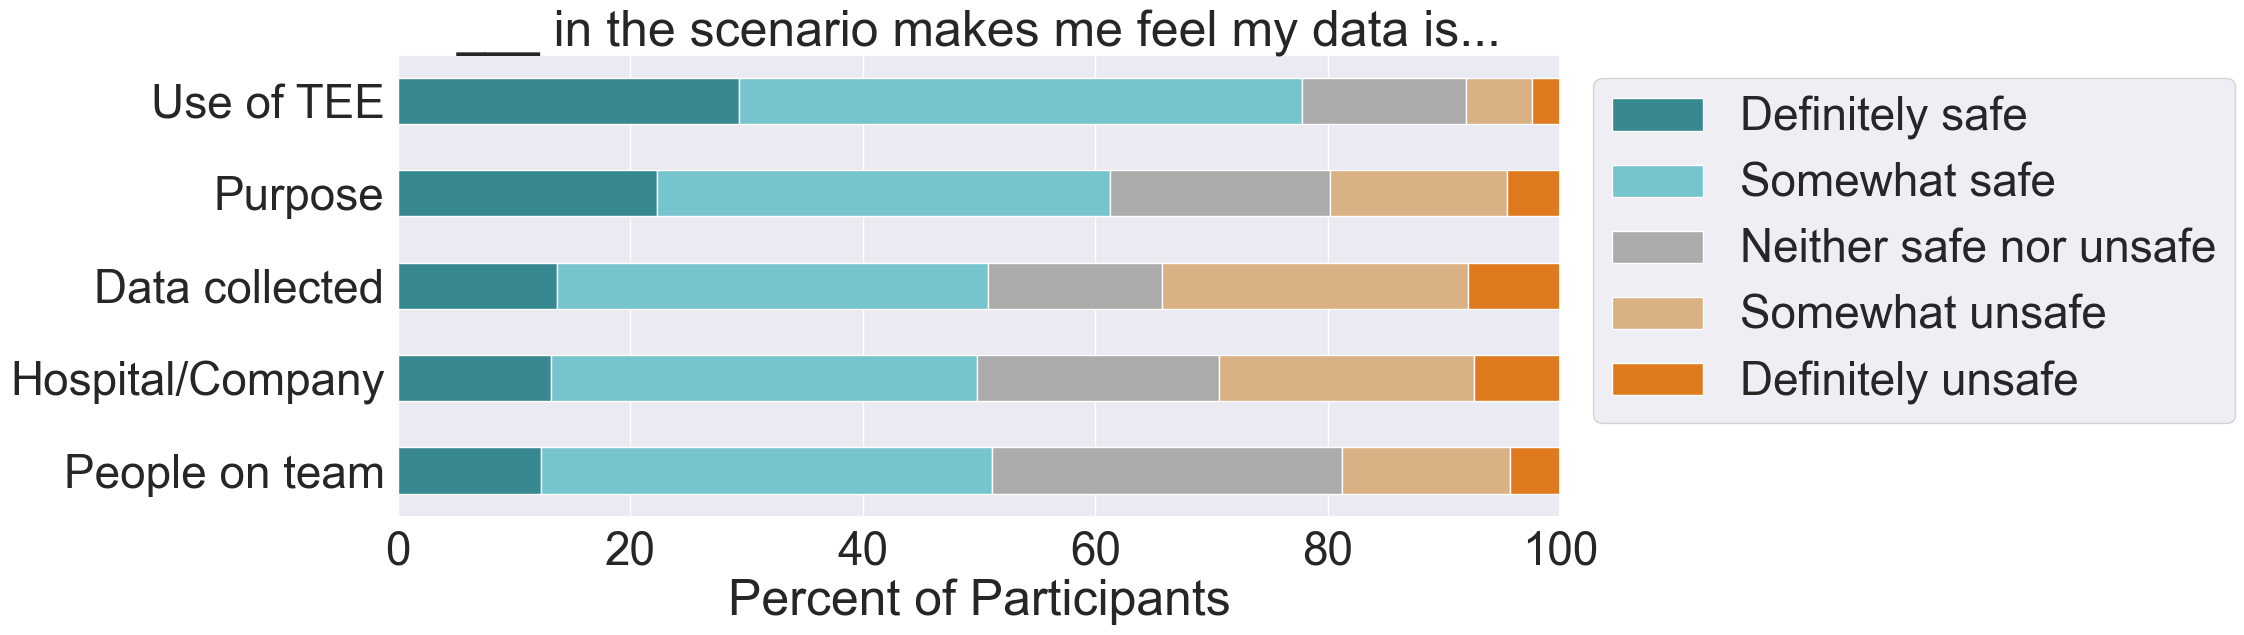

In [ ]:
tee = trust_tee_counts["trust (tee)"]
dest = trust_dest_counts["trust (dest)"]
people = trust_people_counts["trust (people)"]
data = trust_data_counts["trust (data)"]
purpose = trust_purpose_counts["trust (purpose)"]

treatment_safety_chart = pd.DataFrame(tee/sum(tee) * 100).rename(
        columns={"trust (tee)":"Use of TEE"}) \
    .join(pd.DataFrame(dest/sum(dest) * 100).rename(
        columns={"trust (dest)":"Hospital/Company"})) \
    .join(pd.DataFrame(people/sum(people) * 100).rename(
        columns={"trust (people)":"People on team"})) \
    .join(pd.DataFrame(data/sum(data) * 100).rename(
        columns={"trust (data)":"Data collected"})) \
    .join(pd.DataFrame(purpose/sum(purpose) * 100).rename(
        columns={"trust (purpose)":"Purpose"}))

sns.set(font_scale=3)
sns.set_palette(['#388892','#75C4CE','#ABABAB','#DAB085','#E07A1F'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(15, 6))
ax.set_title('___ in the scenario makes me feel my data is...')
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper right', bbox_to_anchor=(1.6, 1)) 

### Per Scenario

Complex medical Scenario

In [ ]:
trust_tee_results = medical_trust_tee_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = medical_trust_hospital_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = medical_trust_people_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = medical_trust_data_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = medical_trust_purpose_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)

trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(trust_tee_results)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(trust_tee_results)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(trust_tee_results)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(trust_tee_results)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(trust_tee_results)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,30.7%,20.7%,13.5%,13.9%,29.1%
Somewhat safe,40.6%,37.8%,42.2%,31.5%,35.9%
Neither safe nor unsafe,18.7%,19.1%,24.3%,14.7%,17.5%
Somewhat unsafe,7.6%,18.3%,15.5%,29.9%,13.5%
Definitely unsafe,2.4%,4.0%,4.4%,10.0%,4.0%


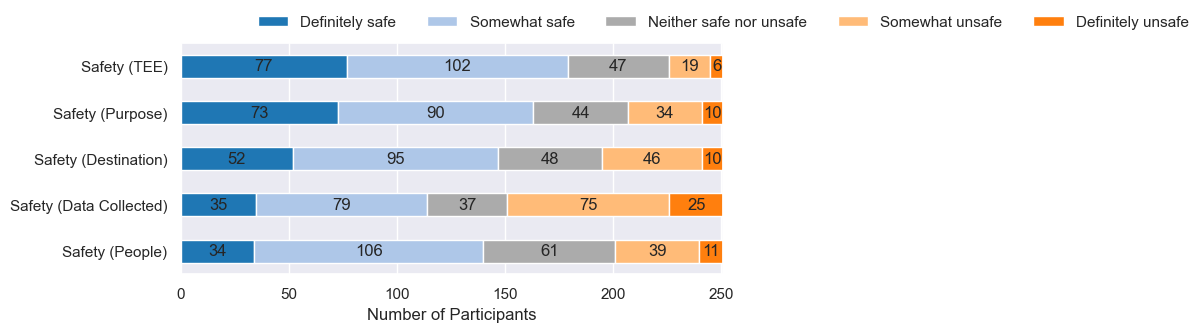

In [ ]:
treatment_safety_chart = pd.DataFrame(trust_tee_counts["trust (tee)"]).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts["trust (dest)"]).rename(
        columns={"trust (dest)":"Safety (Destination)"})) \
    .join(pd.DataFrame(trust_people_counts["trust (people)"]).rename(
        columns={"trust (people)":"Safety (People)"})) \
    .join(pd.DataFrame(trust_data_counts["trust (data)"]).rename(
        columns={"trust (data)":"Safety (Data Collected)"})) \
    .join(pd.DataFrame(trust_purpose_counts["trust (purpose)"]).rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))

sns.set(font_scale=1)
sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
ax.set_xlabel('Number of Participants')
ax.set_xlim(0,max(
    [len(trust_tee_results)]))
# ax.set_ylabel('Goals for Home Automation')
#ax.legend(title='Perceived safety of data, when protected by a TEE')
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, 1), frameon=False, ncol = 5) 

Simple Medical Scenario

In [ ]:
trust_tee_results = medical_trust_tee_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = medical_trust_hospital_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = medical_trust_people_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = medical_trust_data_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = medical_trust_purpose_results.loc[medical_trust_tee_results["Scenario"] == "Medical-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)

trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(trust_tee_results)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(trust_tee_results)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(trust_tee_results)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(trust_tee_results)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(trust_tee_results)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,27.2%,20.7%,13.8%,13.8%,31.7%
Somewhat safe,53.7%,48.8%,43.1%,39.8%,40.2%
Neither safe nor unsafe,11.4%,16.3%,29.3%,19.1%,15.9%
Somewhat unsafe,5.7%,11.0%,10.6%,21.1%,9.8%
Definitely unsafe,2.0%,3.3%,3.3%,6.1%,2.4%


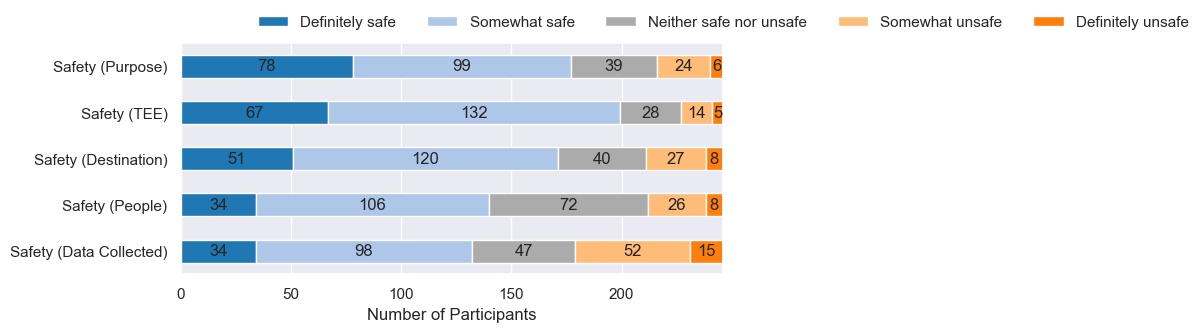

In [ ]:
treatment_safety_chart = pd.DataFrame(trust_tee_counts["trust (tee)"]).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts["trust (dest)"]).rename(
        columns={"trust (dest)":"Safety (Destination)"})) \
    .join(pd.DataFrame(trust_people_counts["trust (people)"]).rename(
        columns={"trust (people)":"Safety (People)"})) \
    .join(pd.DataFrame(trust_data_counts["trust (data)"]).rename(
        columns={"trust (data)":"Safety (Data Collected)"})) \
    .join(pd.DataFrame(trust_purpose_counts["trust (purpose)"]).rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
ax.set_xlabel('Number of Participants')
ax.set_xlim(0,max(
    [len(trust_tee_results)]))
# ax.set_ylabel('Goals for Home Automation')
#ax.legend(title='Perceived safety of data, when protected by a TEE')
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, 1), frameon=False, ncol = 5) 

Complex Home IoT Scenario

In [ ]:
trust_tee_results = iot_trust_tee_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = iot_trust_company_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = iot_trust_people_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = iot_trust_data_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = iot_trust_purpose_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Complex"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)

trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(trust_tee_results)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(trust_tee_results)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(trust_tee_results)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(trust_tee_results)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(trust_tee_results)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,32.4%,5.6%,12.0%,11.2%,12.0%
Somewhat safe,46.0%,26.0%,32.8%,38.8%,37.6%
Neither safe nor unsafe,11.6%,22.8%,32.0%,11.6%,20.8%
Somewhat unsafe,7.2%,31.6%,18.8%,28.8%,21.6%
Definitely unsafe,2.8%,14.0%,4.4%,9.6%,8.0%


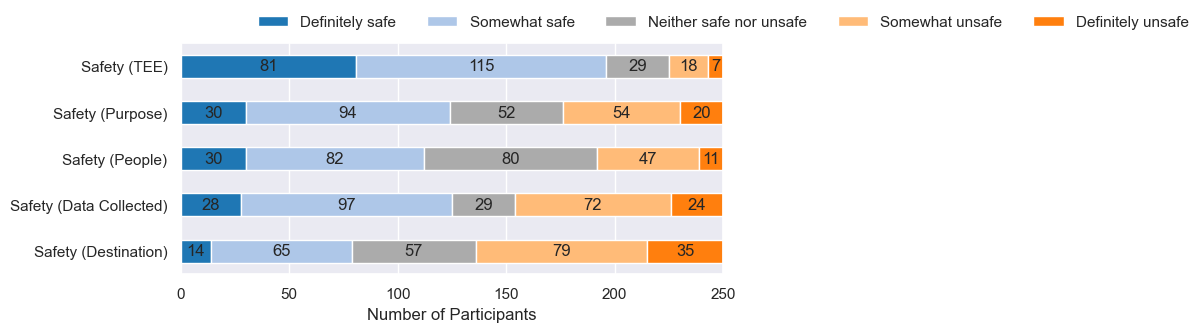

In [ ]:
treatment_safety_chart = pd.DataFrame(trust_tee_counts["trust (tee)"]).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts["trust (dest)"]).rename(
        columns={"trust (dest)":"Safety (Destination)"})) \
    .join(pd.DataFrame(trust_people_counts["trust (people)"]).rename(
        columns={"trust (people)":"Safety (People)"})) \
    .join(pd.DataFrame(trust_data_counts["trust (data)"]).rename(
        columns={"trust (data)":"Safety (Data Collected)"})) \
    .join(pd.DataFrame(trust_purpose_counts["trust (purpose)"]).rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
ax.set_xlabel('Number of Participants')
ax.set_xlim(0,max(
    [len(trust_tee_results)]))
# ax.set_ylabel('Goals for Home Automation')
#ax.legend(title='Perceived safety of data, when protected by a TEE')
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, 1), frameon=False, ncol = 5) 

Simple Home IoT Scenario

In [ ]:
trust_tee_results = iot_trust_tee_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = iot_trust_company_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = iot_trust_people_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = iot_trust_data_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = iot_trust_purpose_results.loc[iot_trust_tee_results["Scenario"] == "IoT-Simple"] \
        .drop(["Scenario", "Expln", "FAQ", "count1", "count2", "count3"],axis=1)

trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(trust_tee_results)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(trust_tee_results)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(trust_tee_results)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(trust_tee_results)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(trust_tee_results)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,27.1%,5.7%,9.7%,15.8%,16.6%
Somewhat safe,53.4%,34.0%,37.2%,38.5%,42.1%
Neither safe nor unsafe,14.6%,25.1%,34.8%,14.2%,21.5%
Somewhat unsafe,2.4%,26.7%,13.0%,25.5%,15.8%
Definitely unsafe,2.4%,8.5%,5.3%,6.1%,4.0%


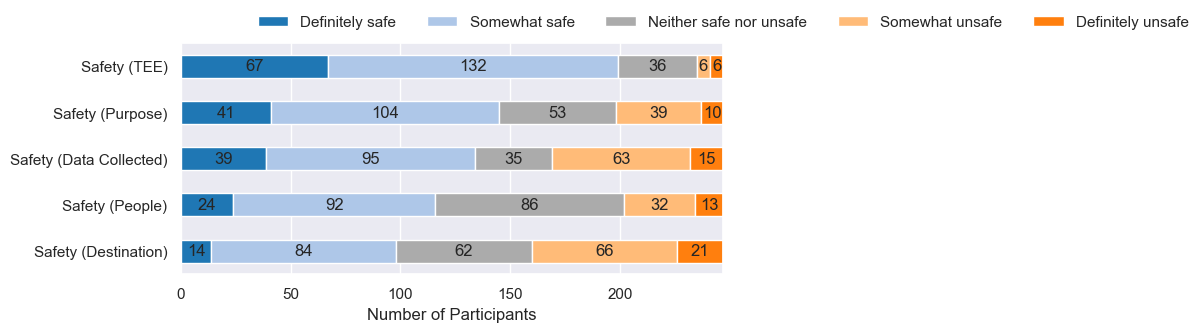

In [ ]:
treatment_safety_chart = pd.DataFrame(trust_tee_counts["trust (tee)"]).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts["trust (dest)"]).rename(
        columns={"trust (dest)":"Safety (Destination)"})) \
    .join(pd.DataFrame(trust_people_counts["trust (people)"]).rename(
        columns={"trust (people)":"Safety (People)"})) \
    .join(pd.DataFrame(trust_data_counts["trust (data)"]).rename(
        columns={"trust (data)":"Safety (Data Collected)"})) \
    .join(pd.DataFrame(trust_purpose_counts["trust (purpose)"]).rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
ax.set_xlabel('Number of Participants')
ax.set_xlim(0,max(
    [len(trust_tee_results)]))
# ax.set_ylabel('Goals for Home Automation')
#ax.legend(title='Perceived safety of data, when protected by a TEE')
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, 1), frameon=False, ncol = 5) 

### Per TEE Explanation Condition

Hardware Explanation Condition

In [ ]:
hw_tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hw_dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hw_people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hw_data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hw_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
none_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

hw_tee_counts = hw_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_dest_counts = hw_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_people_counts = hw_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_data_counts = hw_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_purpose_counts = hw_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_tee_counts = unsub_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_dest_counts = unsub_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_people_counts = unsub_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_data_counts = unsub_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_purpose_counts = unsub_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_tee_counts = none_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_dest_counts = none_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_people_counts = none_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_data_counts = none_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_purpose_counts = none_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(hw_tee_counts).rename(
        columns={"trust (tee)":"HW (TEE)"}) \
    .join(pd.DataFrame(hw_dest_counts.rename(
        columns={"trust (dest)":"HW (Destination)"}))) \
    .join(pd.DataFrame(hw_people_counts.rename(
        columns={"trust (people)":"HW (People)"}))) \
    .join(pd.DataFrame(hw_data_counts.rename(
        columns={"trust (data)":"HW (Data Collected)"}))) \
    .join(pd.DataFrame(hw_purpose_counts.rename(
        columns={"trust (purpose)":"HW (Purpose)"}))) \
    .join(pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Trust (TEE)"})) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Trust (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Trust (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Trust (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Trust (Purpose)"}))) \
    .join(pd.DataFrame(unsub_tee_counts).rename(
        columns={"trust (tee)":"Unsub (TEE)"})) \
    .join(pd.DataFrame(unsub_dest_counts.rename(
        columns={"trust (dest)":"Unsub (Destination)"}))) \
    .join(pd.DataFrame(unsub_people_counts.rename(
        columns={"trust (people)":"Unsub (People)"}))) \
    .join(pd.DataFrame(unsub_data_counts.rename(
        columns={"trust (data)":"Unsub (Data Collected)"}))) \
    .join(pd.DataFrame(unsub_purpose_counts.rename(
        columns={"trust (purpose)":"Unsub (Purpose)"}))) \
    .join(pd.DataFrame(none_tee_counts).rename(
        columns={"trust (tee)":"None (TEE)"})) \
    .join(pd.DataFrame(none_dest_counts.rename(
        columns={"trust (dest)":"None (Destination)"}))) \
    .join(pd.DataFrame(none_people_counts.rename(
        columns={"trust (people)":"None (People)"}))) \
    .join(pd.DataFrame(none_data_counts.rename(
        columns={"trust (data)":"None (Data Collected)"}))) \
    .join(pd.DataFrame(none_purpose_counts.rename(
        columns={"trust (purpose)":"None (Purpose)"}))) 

all_safety["HW (TEE)"] = all_safety["HW (TEE)"] / len(hw_tee_results)
all_safety["HW (Destination)"] = all_safety["HW (Destination)"] / len(hw_dest_results)
all_safety["HW (People)"] = all_safety["HW (People)"] / len(hw_people_results)
all_safety["HW (Data Collected)"] = all_safety["HW (Data Collected)"] / len(hw_data_results)
all_safety["HW (Purpose)"] = all_safety["HW (Purpose)"] / len(hw_purpose_results)
all_safety["Trust (TEE)"] = all_safety["Trust (TEE)"] / len(trust_tee_results)
all_safety["Trust (Destination)"] = all_safety["Trust (Destination)"] / len(trust_dest_results)
all_safety["Trust (People)"] = all_safety["Trust (People)"] / len(trust_people_results)
all_safety["Trust (Data Collected)"] = all_safety["Trust (Data Collected)"] / len(trust_data_results)
all_safety["Trust (Purpose)"] = all_safety["Trust (Purpose)"] / len(trust_purpose_results)
all_safety["Unsub (TEE)"] = all_safety["Unsub (TEE)"] / len(unsub_tee_results)
all_safety["Unsub (Destination)"] = all_safety["Unsub (Destination)"] / len(unsub_dest_results)
all_safety["Unsub (People)"] = all_safety["Unsub (People)"] / len(unsub_people_results)
all_safety["Unsub (Data Collected)"] = all_safety["Unsub (Data Collected)"] / len(unsub_data_results)
all_safety["Unsub (Purpose)"] = all_safety["Unsub (Purpose)"] / len(unsub_purpose_results)
all_safety["None (TEE)"] = all_safety["None (TEE)"] / len(none_tee_results)
all_safety["None (Destination)"] = all_safety["None (Destination)"] / len(none_dest_results)
all_safety["None (People)"] = all_safety["None (People)"] / len(none_people_results)
all_safety["None (Data Collected)"] = all_safety["None (Data Collected)"] / len(none_data_results)
all_safety["None (Purpose)"] = all_safety["None (Purpose)"] / len(none_purpose_results)

all_safety.style.format('{:.1%}')



,HW (TEE),HW (Destination),HW (People),HW (Data Collected),HW (Purpose),Trust (TEE),Trust (Destination),Trust (People),Trust (Data Collected),Trust (Purpose),Unsub (TEE),Unsub (Destination),Unsub (People),Unsub (Data Collected),Unsub (Purpose),None (TEE),None (Destination),None (People),None (Data Collected),None (Purpose)
Definitely safe,38.4%,13.6%,13.2%,12.4%,25.2%,28.5%,13.0%,12.2%,13.4%,17.9%,29.5%,12.2%,12.6%,13.4%,24.4%,20.9%,13.9%,11.1%,15.6%,21.7%
Somewhat safe,44.8%,35.6%,44.0%,36.8%,37.2%,49.2%,31.7%,31.7%,33.7%,38.2%,48.8%,40.2%,38.2%,42.5%,38.6%,50.8%,38.9%,41.4%,35.2%,41.8%
Neither safe nor unsafe,7.2%,22.4%,25.6%,13.2%,18.0%,11.0%,19.9%,35.0%,15.9%,18.3%,16.9%,19.7%,29.1%,15.4%,20.1%,21.3%,21.3%,30.7%,15.2%,19.3%
Somewhat unsafe,6.4%,23.2%,14.0%,30.4%,15.2%,9.3%,26.0%,14.2%,26.4%,20.7%,3.5%,20.1%,16.5%,20.9%,12.2%,3.7%,18.4%,13.1%,27.9%,12.7%
Definitely unsafe,3.2%,5.2%,3.2%,7.2%,4.4%,2.0%,9.3%,6.9%,10.6%,4.9%,1.2%,7.9%,3.5%,7.9%,4.7%,3.3%,7.4%,3.7%,6.1%,4.5%


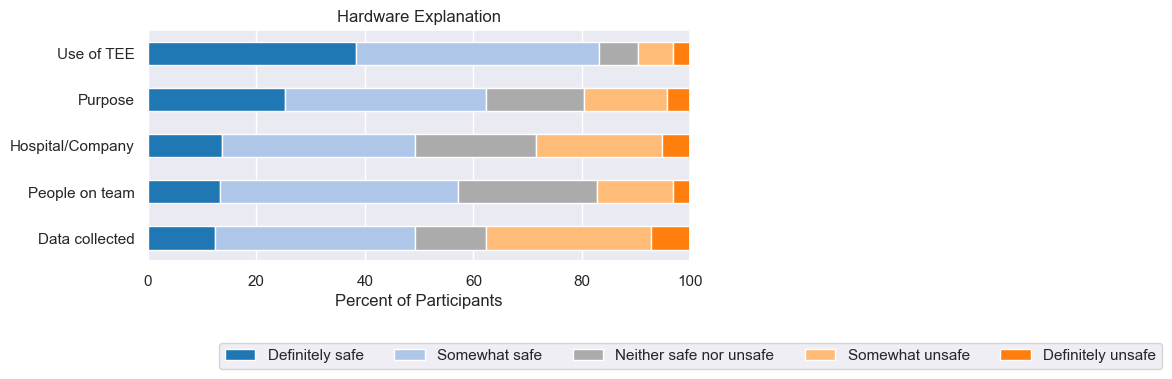

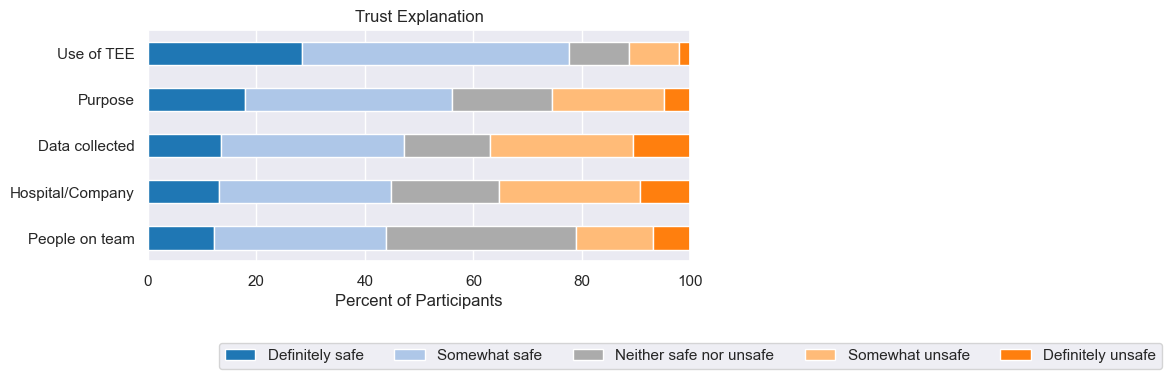

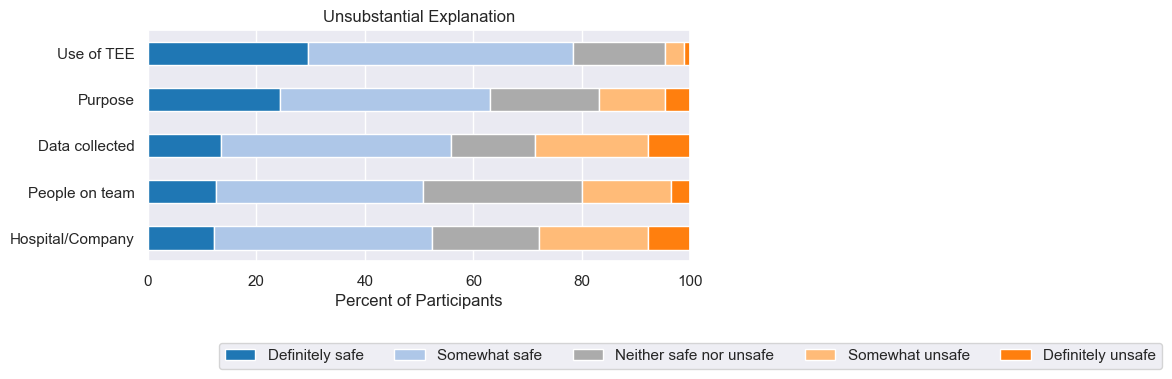

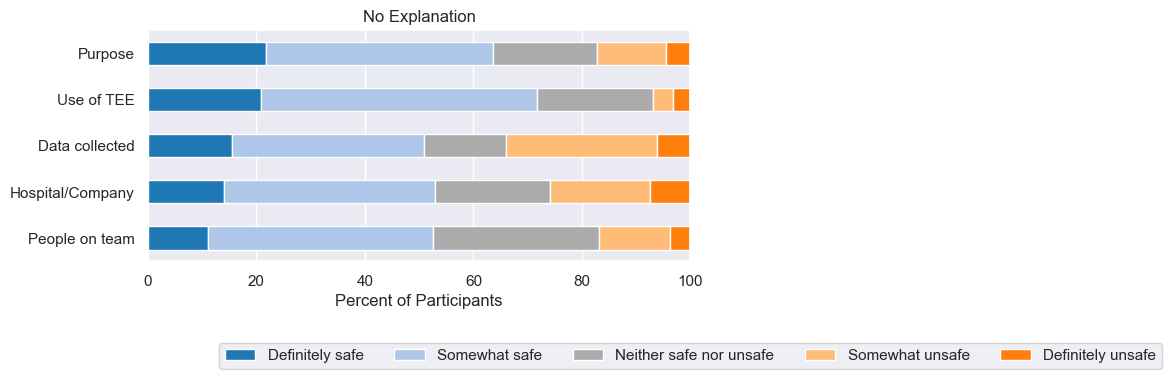

In [ ]:
tee = hw_tee_counts["trust (tee)"]
dest = hw_dest_counts["trust (dest)"]
people = hw_people_counts["trust (people)"]
data = hw_data_counts["trust (data)"]
purpose = hw_purpose_counts["trust (purpose)"]

treatment_safety_chart = pd.DataFrame(tee/sum(tee) * 100).rename(
        columns={"trust (tee)":"Use of TEE"}) \
    .join(pd.DataFrame(dest/sum(dest) * 100).rename(
        columns={"trust (dest)":"Hospital/Company"})) \
    .join(pd.DataFrame(people/sum(people) * 100).rename(
        columns={"trust (people)":"People on team"})) \
    .join(pd.DataFrame(data/sum(data) * 100).rename(
        columns={"trust (data)":"Data collected"})) \
    .join(pd.DataFrame(purpose/sum(purpose) * 100).rename(
        columns={"trust (purpose)":"Purpose"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
ax.set_title('Hardware Explanation')
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, -0.5), ncol = 5) 

##########################################################################

tee = trust_tee_counts["trust (tee)"]
dest = trust_dest_counts["trust (dest)"]
people = trust_people_counts["trust (people)"]
data = trust_data_counts["trust (data)"]
purpose = trust_purpose_counts["trust (purpose)"]

treatment_safety_chart = pd.DataFrame(tee/sum(tee) * 100).rename(
        columns={"trust (tee)":"Use of TEE"}) \
    .join(pd.DataFrame(dest/sum(dest) * 100).rename(
        columns={"trust (dest)":"Hospital/Company"})) \
    .join(pd.DataFrame(people/sum(people) * 100).rename(
        columns={"trust (people)":"People on team"})) \
    .join(pd.DataFrame(data/sum(data) * 100).rename(
        columns={"trust (data)":"Data collected"})) \
    .join(pd.DataFrame(purpose/sum(purpose) * 100).rename(
        columns={"trust (purpose)":"Purpose"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
ax.set_title('Trust Explanation')
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, -0.5), ncol = 5) 

##########################################################################

tee = unsub_tee_counts["trust (tee)"]
dest = unsub_dest_counts["trust (dest)"]
people = unsub_people_counts["trust (people)"]
data = unsub_data_counts["trust (data)"]
purpose = unsub_purpose_counts["trust (purpose)"]

treatment_safety_chart = pd.DataFrame(tee/sum(tee) * 100).rename(
        columns={"trust (tee)":"Use of TEE"}) \
    .join(pd.DataFrame(dest/sum(dest) * 100).rename(
        columns={"trust (dest)":"Hospital/Company"})) \
    .join(pd.DataFrame(people/sum(people) * 100).rename(
        columns={"trust (people)":"People on team"})) \
    .join(pd.DataFrame(data/sum(data) * 100).rename(
        columns={"trust (data)":"Data collected"})) \
    .join(pd.DataFrame(purpose/sum(purpose) * 100).rename(
        columns={"trust (purpose)":"Purpose"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
ax.set_title('Unsubstantial Explanation')
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, -0.5), ncol = 5) 

##########################################################################

tee = none_tee_counts["trust (tee)"]
dest = none_dest_counts["trust (dest)"]
people = none_people_counts["trust (people)"]
data = none_data_counts["trust (data)"]
purpose = none_purpose_counts["trust (purpose)"]

treatment_safety_chart = pd.DataFrame(tee/sum(tee) * 100).rename(
        columns={"trust (tee)":"Use of TEE"}) \
    .join(pd.DataFrame(dest/sum(dest) * 100).rename(
        columns={"trust (dest)":"Hospital/Company"})) \
    .join(pd.DataFrame(people/sum(people) * 100).rename(
        columns={"trust (people)":"People on team"})) \
    .join(pd.DataFrame(data/sum(data) * 100).rename(
        columns={"trust (data)":"Data collected"})) \
    .join(pd.DataFrame(purpose/sum(purpose) * 100).rename(
        columns={"trust (purpose)":"Purpose"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
ax.set_title('No Explanation')
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, -0.5), ncol = 5) 


In [ ]:
hw_tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hw_dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hw_people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hw_data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
hw_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "Hardware"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "Trust"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
unsub_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "Unsubstantial"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

none_tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "None"]
none_dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "None"]
none_people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "None"]
none_data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "None"]
none_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "None"]
faq_tee_results = none_tee_results.loc[~(none_tee_results["FAQ"] ==  "None")] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
faq_des_results = none_dest_results.loc[~(none_dest_results["FAQ"] ==  "None")] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
faq_people_results = none_people_results.loc[~(none_people_results["FAQ"] ==  "None")] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
faq_data_results = none_data_results.loc[~(none_data_results["FAQ"] ==  "None")] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
faq_purpose_results = none_purpose_results.loc[~(none_purpose_results["FAQ"] ==  "None")] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

hw_tee_counts = hw_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_dest_counts = hw_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_people_counts = hw_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_data_counts = hw_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
hw_purpose_counts = hw_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_tee_counts = unsub_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_dest_counts = unsub_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_people_counts = unsub_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_data_counts = unsub_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_purpose_counts = unsub_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_tee_counts = faq_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_dest_counts = faq_des_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_people_counts = faq_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_data_counts = faq_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_purpose_counts = faq_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

tee_counts = hw_tee_counts + trust_tee_counts + unsub_tee_counts + faq_tee_counts
dest_counts = hw_dest_counts + trust_dest_counts + unsub_dest_counts + faq_dest_counts
people_counts = hw_people_counts + trust_people_counts + unsub_people_counts + faq_people_counts
data_counts = hw_data_counts + trust_data_counts + unsub_data_counts + faq_data_counts
purpose_counts = hw_purpose_counts + trust_purpose_counts + unsub_purpose_counts + faq_purpose_counts

all_safety = pd.DataFrame(tee_counts).rename(
        columns={"trust (tee)":"TEE"}) \
    .join(pd.DataFrame(dest_counts.rename(
        columns={"trust (dest)":"Destination"}))) \
    .join(pd.DataFrame(people_counts.rename(
        columns={"trust (people)":"People"}))) \
    .join(pd.DataFrame(data_counts.rename(
        columns={"trust (data)":"Data Collected"}))) \
    .join(pd.DataFrame(purpose_counts.rename(
        columns={"trust (purpose)":"Purpose"})))

all_safety["TEE"] = all_safety["TEE"] / sum(all_safety["TEE"])
all_safety["Destination"] = all_safety["Destination"] / sum(all_safety["Destination"])
all_safety["People"] = all_safety["People"] / sum(all_safety["People"])
all_safety["Data Collected"] = all_safety["Data Collected"] / sum(all_safety["Data Collected"])
all_safety["Purpose"] = all_safety["Purpose"] / sum(all_safety["Purpose"])

all_safety.style.format('{:.1%}')

,TEE,Destination,People,Data Collected,Purpose
Definitely safe,31.7%,12.9%,12.5%,13.8%,22.9%
Somewhat safe,48.6%,36.8%,38.3%,36.9%,38.7%
Neither safe nor unsafe,12.2%,20.8%,30.3%,15.2%,18.7%
Somewhat unsafe,5.8%,22.2%,14.9%,26.4%,15.4%
Definitely unsafe,1.8%,7.2%,4.0%,7.6%,4.3%


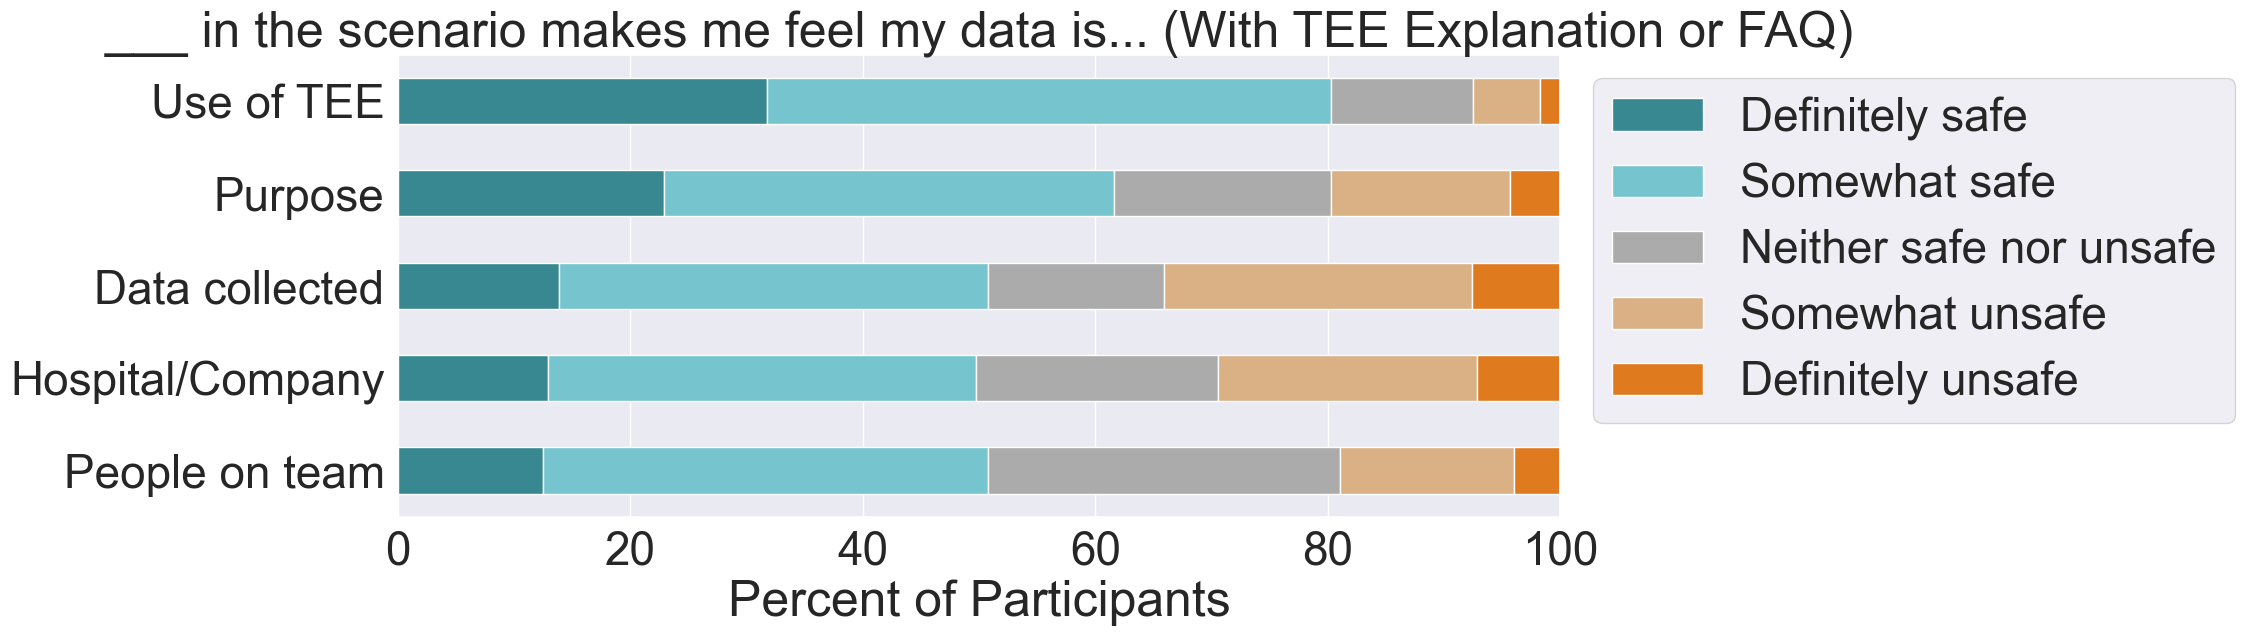

In [ ]:
tee = tee_counts["trust (tee)"]
dest = dest_counts["trust (dest)"]
people = people_counts["trust (people)"]
data = data_counts["trust (data)"]
purpose = purpose_counts["trust (purpose)"]

treatment_safety_chart = pd.DataFrame(tee/sum(tee) * 100).rename(
        columns={"trust (tee)":"Use of TEE"}) \
    .join(pd.DataFrame(dest/sum(dest) * 100).rename(
        columns={"trust (dest)":"Hospital/Company"})) \
    .join(pd.DataFrame(people/sum(people) * 100).rename(
        columns={"trust (people)":"People on team"})) \
    .join(pd.DataFrame(data/sum(data) * 100).rename(
        columns={"trust (data)":"Data collected"})) \
    .join(pd.DataFrame(purpose/sum(purpose) * 100).rename(
        columns={"trust (purpose)":"Purpose"}))

sns.set(font_scale=3)
sns.set_palette(['#388892','#75C4CE','#ABABAB','#DAB085','#E07A1F'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(15, 6))
ax.set_title('___ in the scenario makes me feel my data is... (With TEE Explanation or FAQ)')
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper right', bbox_to_anchor=(1.6, 1)) 

No Explanation or FAQ Condition

In [ ]:
tee_results = overall_trust_tee.loc[overall_trust_tee["Expln"] == "None"]
dest_results = overall_trust_dest.loc[overall_trust_dest["Expln"] == "None"] 
people_results = overall_trust_people.loc[overall_trust_people["Expln"] == "None"] 
data_results = overall_trust_data.loc[overall_trust_data["Expln"] == "None"] 
purpose_results = overall_trust_purpose.loc[overall_trust_purpose["Expln"] == "None"] 

faq_tee_results = tee_results.loc[tee_results["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
faq_dest_results = dest_results.loc[dest_results["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
faq_people_results = people_results.loc[people_results["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
faq_data_results = data_results.loc[data_results["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
faq_purpose_results = purpose_results.loc[purpose_results["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

faq_tee_counts = faq_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_dest_counts = faq_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_people_counts = faq_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_data_counts = faq_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
faq_purpose_counts = faq_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(faq_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(faq_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(faq_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(faq_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(faq_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(faq_tee_results)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(faq_tee_results)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(faq_tee_results)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(faq_tee_results)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(faq_tee_results)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,5.6%,15.6%,10.0%,12.2%,16.7%
Somewhat safe,46.7%,34.4%,44.4%,38.9%,41.1%
Neither safe nor unsafe,33.3%,21.1%,27.8%,12.2%,21.1%
Somewhat unsafe,5.6%,18.9%,10.0%,25.6%,13.3%
Definitely unsafe,8.9%,10.0%,7.8%,11.1%,7.8%


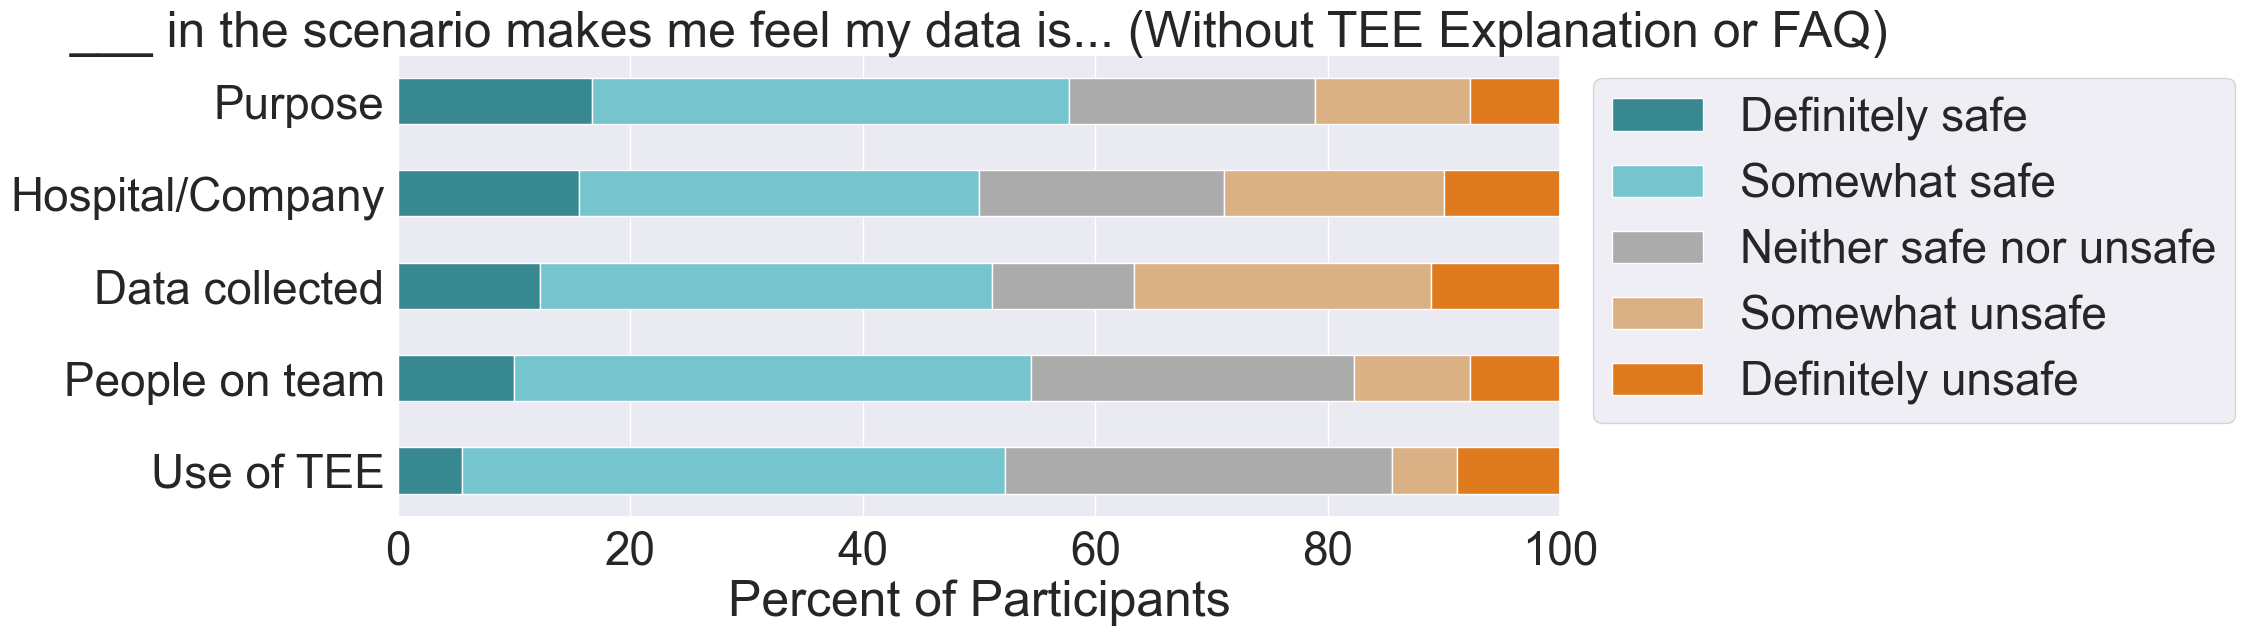

In [ ]:
tee = faq_tee_counts["trust (tee)"]
dest = faq_dest_counts["trust (dest)"]
people = faq_people_counts["trust (people)"]
data = faq_data_counts["trust (data)"]
purpose = faq_purpose_counts["trust (purpose)"]

treatment_safety_chart = pd.DataFrame(tee/sum(tee) * 100).rename(
        columns={"trust (tee)":"Use of TEE"}) \
    .join(pd.DataFrame(dest/sum(dest) * 100).rename(
        columns={"trust (dest)":"Hospital/Company"})) \
    .join(pd.DataFrame(people/sum(people) * 100).rename(
        columns={"trust (people)":"People on team"})) \
    .join(pd.DataFrame(data/sum(data) * 100).rename(
        columns={"trust (data)":"Data collected"})) \
    .join(pd.DataFrame(purpose/sum(purpose) * 100).rename(
        columns={"trust (purpose)":"Purpose"}))

sns.set(font_scale=3)
sns.set_palette(['#388892','#75C4CE','#ABABAB','#DAB085','#E07A1F'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(15, 6))
ax.set_title('___ in the scenario makes me feel my data is... (Without TEE Explanation or FAQ)')
ax.set_xlabel('Percent of Participants')
ax.set_xlim(0,100)
sns.move_legend(ax, 'upper right', bbox_to_anchor=(1.6, 1)) 

### Per FAQ Condition

Show FAQ Condition

In [ ]:
trust_tee_results = overall_trust_tee.loc[overall_trust_tee["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = overall_trust_dest.loc[overall_trust_dest["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = overall_trust_people.loc[overall_trust_people["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = overall_trust_data.loc[overall_trust_data["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["FAQ"] == "Show"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(trust_tee_results)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(trust_tee_results)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(trust_tee_results)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(trust_tee_results)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(trust_tee_results)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,37.8%,15.2%,15.5%,17.4%,25.3%
Somewhat safe,46.3%,36.9%,35.1%,36.6%,37.8%
Neither safe nor unsafe,9.8%,18.6%,28.0%,16.5%,16.8%
Somewhat unsafe,4.9%,21.0%,17.1%,23.8%,16.2%
Definitely unsafe,1.2%,8.2%,4.3%,5.8%,4.0%


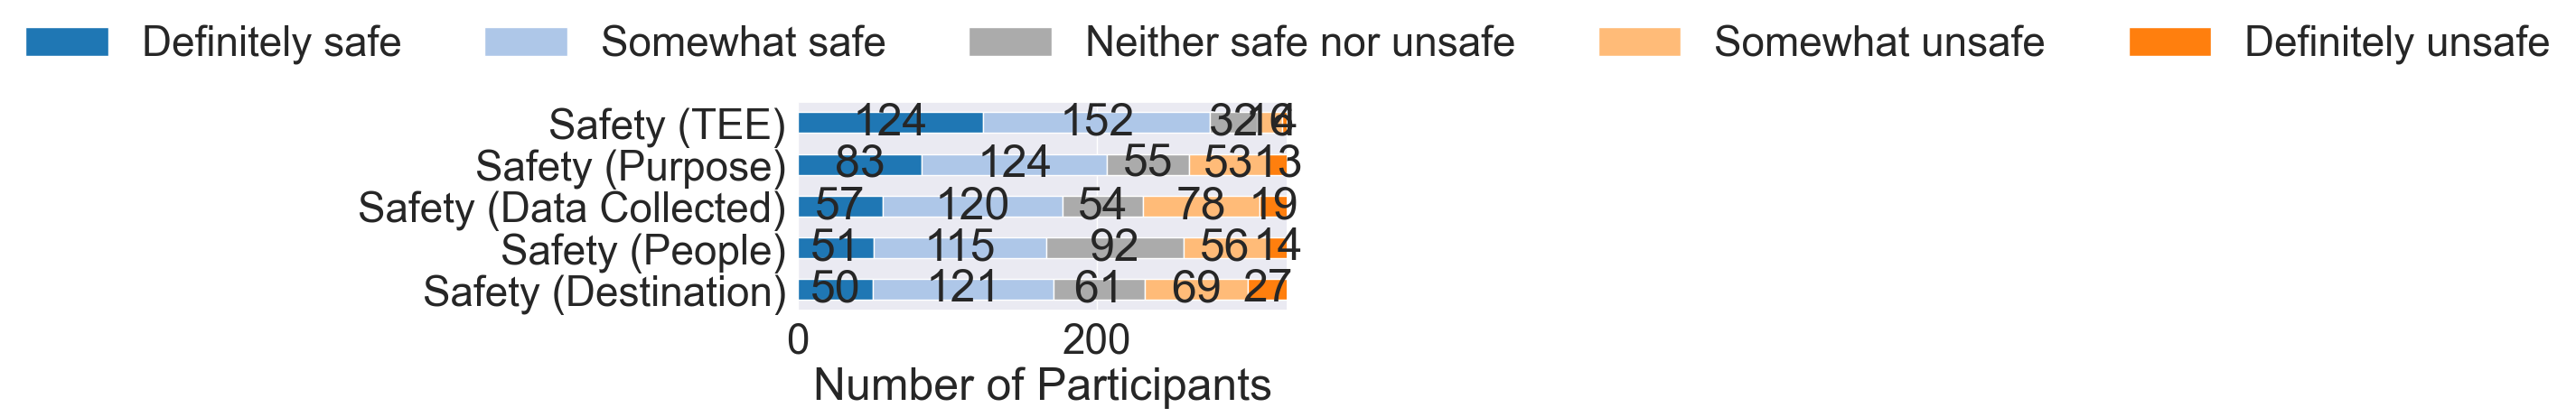

In [ ]:
treatment_safety_chart = pd.DataFrame(trust_tee_counts["trust (tee)"]).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts["trust (dest)"]).rename(
        columns={"trust (dest)":"Safety (Destination)"})) \
    .join(pd.DataFrame(trust_people_counts["trust (people)"]).rename(
        columns={"trust (people)":"Safety (People)"})) \
    .join(pd.DataFrame(trust_data_counts["trust (data)"]).rename(
        columns={"trust (data)":"Safety (Data Collected)"})) \
    .join(pd.DataFrame(trust_purpose_counts["trust (purpose)"]).rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
ax.set_xlabel('Number of Participants')
ax.set_xlim(0,max(
    [len(trust_tee_results)]))
# ax.set_ylabel('Goals for Home Automation')
#ax.legend(title='Perceived safety of data, when protected by a TEE')
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, 1), frameon=False, ncol = 5) 

Hide FAQ Condition

In [ ]:
trust_tee_results = overall_trust_tee.loc[overall_trust_tee["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = overall_trust_dest.loc[overall_trust_dest["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = overall_trust_people.loc[overall_trust_people["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = overall_trust_data.loc[overall_trust_data["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["FAQ"] == "Hide"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(trust_tee_results)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(trust_tee_results)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(trust_tee_results)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(trust_tee_results)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(trust_tee_results)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,32.2%,11.1%,10.2%,13.0%,21.4%
Somewhat safe,45.8%,37.7%,41.6%,39.2%,41.0%
Neither safe nor unsafe,13.6%,22.6%,33.7%,12.3%,18.1%
Somewhat unsafe,6.0%,23.2%,10.8%,26.8%,15.4%
Definitely unsafe,2.4%,5.4%,3.6%,8.7%,4.2%


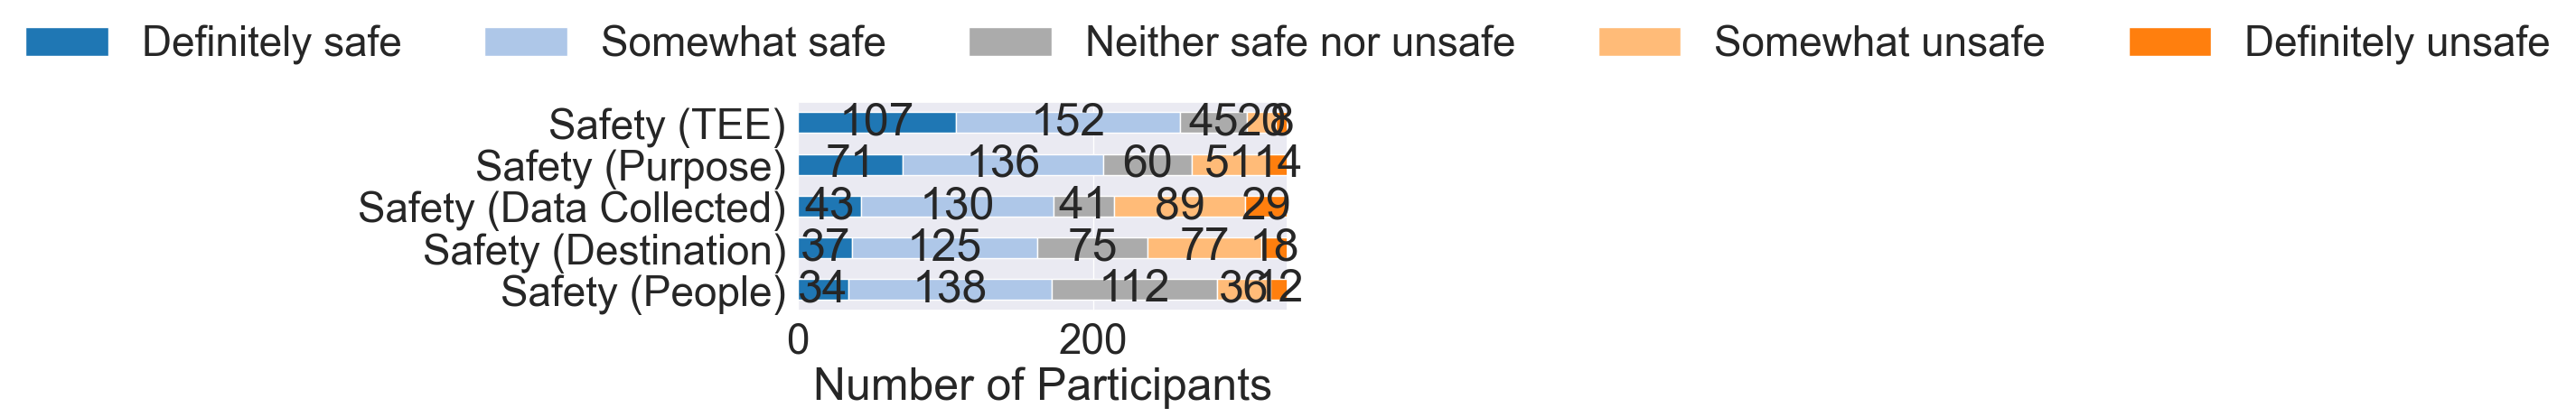

In [ ]:
treatment_safety_chart = pd.DataFrame(trust_tee_counts["trust (tee)"]).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts["trust (dest)"]).rename(
        columns={"trust (dest)":"Safety (Destination)"})) \
    .join(pd.DataFrame(trust_people_counts["trust (people)"]).rename(
        columns={"trust (people)":"Safety (People)"})) \
    .join(pd.DataFrame(trust_data_counts["trust (data)"]).rename(
        columns={"trust (data)":"Safety (Data Collected)"})) \
    .join(pd.DataFrame(trust_purpose_counts["trust (purpose)"]).rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
ax.set_xlabel('Number of Participants')
ax.set_xlim(0,max(
    [len(trust_tee_results)]))
# ax.set_ylabel('Goals for Home Automation')
#ax.legend(title='Perceived safety of data, when protected by a TEE')
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, 1), frameon=False, ncol = 5) 

No FAQ Condition

In [ ]:
trust_tee_results = overall_trust_tee.loc[overall_trust_tee["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_dest_results = overall_trust_dest.loc[overall_trust_dest["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_people_results = overall_trust_people.loc[overall_trust_people["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_data_results = overall_trust_data.loc[overall_trust_data["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)
trust_purpose_results = overall_trust_purpose.loc[overall_trust_purpose["FAQ"] == "None"] \
        .drop(["Expln", "FAQ", "count1", "count2", "count3"],axis=1)

trust_tee_counts = trust_tee_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_dest_counts = trust_dest_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_people_counts = trust_people_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_data_counts = trust_data_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_purpose_counts = trust_purpose_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)

all_safety = pd.DataFrame(trust_tee_counts).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts.rename(
        columns={"trust (dest)":"Safety (Destination)"}))) \
    .join(pd.DataFrame(trust_people_counts.rename(
        columns={"trust (people)":"Safety (People)"}))) \
    .join(pd.DataFrame(trust_data_counts.rename(
        columns={"trust (data)":"Safety (Data Collected)"}))) \
    .join(pd.DataFrame(trust_purpose_counts.rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))) 

all_safety["Safety (TEE)"] = all_safety["Safety (TEE)"] / len(trust_tee_results)
all_safety["Safety (Destination)"] = all_safety["Safety (Destination)"] / len(trust_tee_results)
all_safety["Safety (People)"] = all_safety["Safety (People)"] / len(trust_tee_results)
all_safety["Safety (Data Collected)"] = all_safety["Safety (Data Collected)"] / len(trust_tee_results)
all_safety["Safety (Purpose)"] = all_safety["Safety (Purpose)"] / len(trust_tee_results)

all_safety.style.format('{:.1%}')

,Safety (TEE),Safety (Destination),Safety (People),Safety (Data Collected),Safety (Purpose)
Definitely safe,18.3%,13.2%,11.1%,10.8%,20.4%
Somewhat safe,53.0%,35.3%,39.8%,35.6%,38.0%
Neither safe nor unsafe,18.9%,21.3%,28.4%,15.9%,21.9%
Somewhat unsafe,6.3%,21.6%,15.6%,28.4%,14.1%
Definitely unsafe,3.6%,8.7%,5.1%,9.3%,5.7%


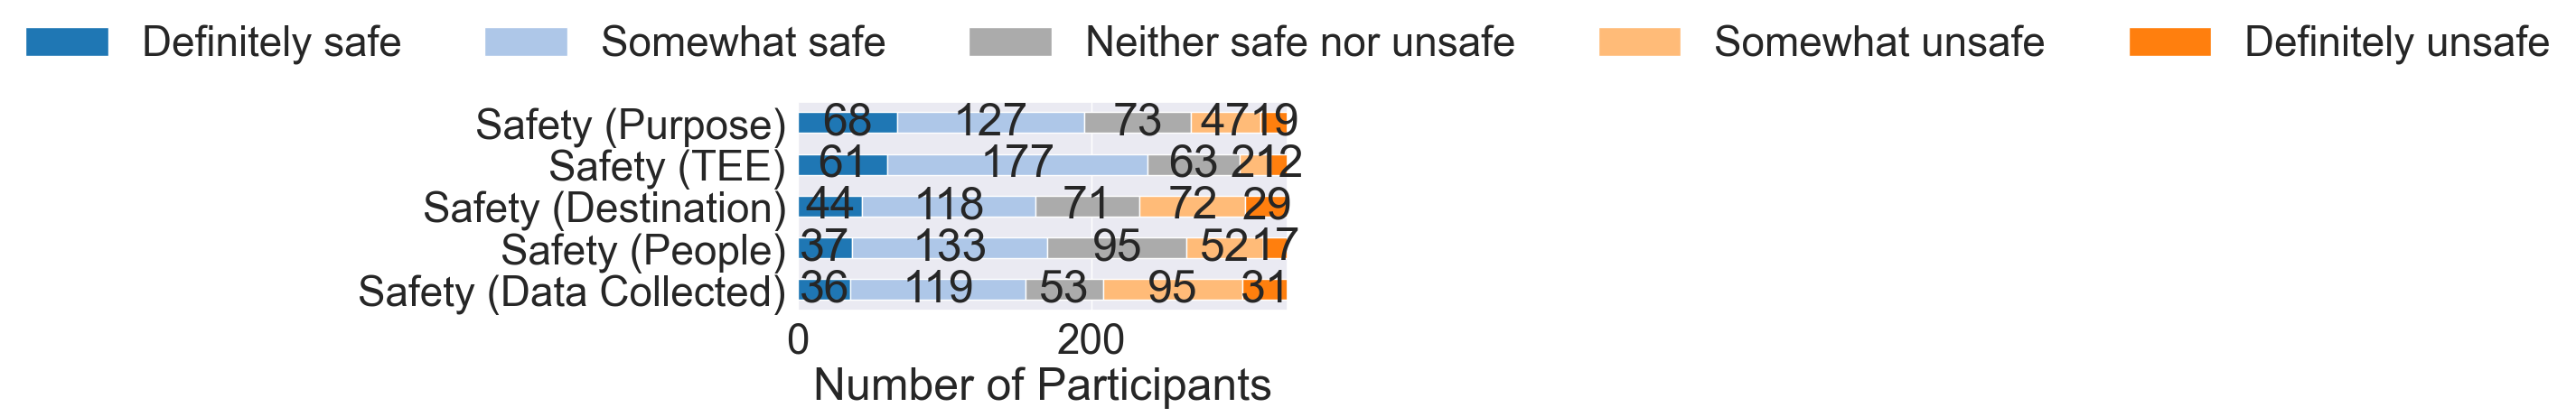

In [ ]:
treatment_safety_chart = pd.DataFrame(trust_tee_counts["trust (tee)"]).rename(
        columns={"trust (tee)":"Safety (TEE)"}) \
    .join(pd.DataFrame(trust_dest_counts["trust (dest)"]).rename(
        columns={"trust (dest)":"Safety (Destination)"})) \
    .join(pd.DataFrame(trust_people_counts["trust (people)"]).rename(
        columns={"trust (people)":"Safety (People)"})) \
    .join(pd.DataFrame(trust_data_counts["trust (data)"]).rename(
        columns={"trust (data)":"Safety (Data Collected)"})) \
    .join(pd.DataFrame(trust_purpose_counts["trust (purpose)"]).rename(
        columns={"trust (purpose)":"Safety (Purpose)"}))

sns.set_palette(['#1F77B4','#AEC7E8','#ABABAB','#FFBB78','#FF7F0E'], n_colors=5)
ax = treatment_safety_chart.transpose() \
    .sort_values(by=["Definitely safe", "Somewhat safe"]) \
    .plot(kind='barh', stacked=True, figsize=(7, 3))
for bars in ax.containers:
    ax.bar_label(bars, label_type='center')
ax.set_xlabel('Number of Participants')
ax.set_xlim(0,max(
    [len(trust_tee_results)]))
# ax.set_ylabel('Goals for Home Automation')
#ax.legend(title='Perceived safety of data, when protected by a TEE')
sns.move_legend(ax, 'lower center', bbox_to_anchor=(1, 1), frameon=False, ncol = 5) 

Per TEE Explanation (Show FAQ, trust TEE only)

In [ ]:
trust_tee_results = overall_trust_tee.loc[overall_trust_tee["FAQ"] == "Show"] \
        .drop(["FAQ", "count1", "count2", "count3"],axis=1)

hw_show_results = trust_tee_results.loc[trust_tee_results["Expln"] == "Hardware"] \
        .drop(["Expln"],axis=1)
trust_show_results = trust_tee_results.loc[trust_tee_results["Expln"] == "Trust"] \
        .drop(["Expln"],axis=1)
unsub_show_results = trust_tee_results.loc[trust_tee_results["Expln"] == "Unsubstantial"] \
        .drop(["Expln"],axis=1)
none_show_results = trust_tee_results.loc[trust_tee_results["Expln"] == "None"] \
        .drop(["Expln"],axis=1)

hw_show_counts = hw_show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
trust_show_counts = trust_show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
unsub_show_counts = unsub_show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)
none_show_counts = none_show_results.apply(lambda col: col.value_counts()).reindex(safety_scale).fillna(0)


all_safety = pd.DataFrame(hw_show_counts).rename(
        columns={"trust (tee)":"Hardware"}) \
    .join(pd.DataFrame(trust_show_counts.rename(
        columns={"trust (tee)":"Trust"}))) \
    .join(pd.DataFrame(unsub_show_counts.rename(
        columns={"trust (tee)":"Unsubstantial"}))) \
    .join(pd.DataFrame(none_show_counts.rename(
        columns={"trust (tee)":"None"})))

all_safety["Hardware"] = all_safety["Hardware"] / len(hw_show_results)
all_safety["Trust"] = all_safety["Trust"] / len(trust_show_results)
all_safety["Unsubstantial"] = all_safety["Unsubstantial"] / len(unsub_show_results)
all_safety["None"] = all_safety["None"] / len(none_show_results)

all_safety.style.format('{:.1%}')

,Hardware,Trust,Unsubstantial,None
Definitely safe,41.7%,30.4%,50.0%,31.0%
Somewhat safe,44.4%,45.7%,37.5%,57.1%
Neither safe nor unsafe,9.7%,12.0%,8.8%,8.3%
Somewhat unsafe,4.2%,9.8%,1.2%,3.6%
Definitely unsafe,0.0%,2.2%,2.5%,0.0%


# Question Analysis

In [ ]:
qual_results = pd.read_csv('./export_followup/qualitative_data_coded.csv', encoding=ENCODING)

medical_qual_results = qual_results[["med_distrust", "med_risk", "med_risk2",
            "med_gen", "med_gen2", "med_use", "med_scenario", "med_scenario2", "med_guarantees",
            "SCENARIO_Med", "EXPLN", "FAQ"]]
iot_qual_results = qual_results[["iot_distrust", "iot_risk", "iot_risk2",
            "iot_gen", "iot_gen2", "iot_use", "iot_scenario", "iot_scenario2", "iot_guarantees",
            "SCENARIO_IoT", "EXPLN", "FAQ"]]

medicalC_results_all = medical_qual_results.loc[medical_qual_results["SCENARIO_Med"] == "Medical-Complex"] \
    .drop(["SCENARIO_Med","EXPLN", "FAQ"],axis=1)
medicalS_results_all = medical_qual_results.loc[medical_qual_results["SCENARIO_Med"] == "Medical-Simple"] \
    .drop(["SCENARIO_Med","EXPLN", "FAQ"],axis=1)
iotC_results_all = iot_qual_results.loc[iot_qual_results["SCENARIO_IoT"] == "IoT-Complex"] \
    .drop(["SCENARIO_IoT","EXPLN", "FAQ"],axis=1)
iotS_results_all = iot_qual_results.loc[iot_qual_results["SCENARIO_IoT"] == "IoT-Simple"] \
    .drop(["SCENARIO_IoT","EXPLN", "FAQ"],axis=1)

In [ ]:
count_med_coded = medical_qual_results.drop(["EXPLN", "FAQ", "SCENARIO_Med"], axis=1)
count_iot_coded = iot_qual_results.drop(["EXPLN", "FAQ", "SCENARIO_IoT"], axis=1)

med_code_count = count_med_coded.count(axis=1).astype(bool).sum(axis=0)
iot_code_count = count_iot_coded.count(axis=1).astype(bool).sum(axis=0)

all_count = qual_results.drop(["ResponseId", "id", 
    "What questions do you still have about TEEs, if any? (medical)", "SCENARIO_Med", 
    "questions-IoT", "SCENARIO_IoT", "EXPLN", "FAQ", 
    "notes", "Other feedback", "code_feedback", "Med_First"], axis=1)

print("Total number of questions coded  (medical): " + str(med_code_count))
print("Total number of questions coded (IoT): " + str(iot_code_count))
print("Total number of questions coded: " + str(med_code_count + iot_code_count) 
      + " from " + str(all_count.count(axis=1).astype(bool).sum(axis=0)) + " people")

Total number of questions coded  (medical): 136
Total number of questions coded (IoT): 131
Total number of questions coded: 267 from 214 people


In [ ]:
medicalC_code_counts = medicalC_results_all.apply(lambda col: col.value_counts()).fillna(0)
medicalS_code_counts = medicalS_results_all.apply(lambda col: col.value_counts()).fillna(0)
iotC_code_counts = iotC_results_all.apply(lambda col: col.value_counts()).fillna(0)
iotS_code_counts = iotS_results_all.apply(lambda col: col.value_counts()).fillna(0)

# set up new dataframe with all qual codes
## need to re-index dataframes since we used med_ for medical codes and iot_ for iot codes
all_categories = pd.DataFrame(medicalC_code_counts.sum(axis=0),columns=["Medical Complex"]) \
        .rename(index=dict(zip(medicalC_code_counts.columns, surveyfieldsfollowup.qualCategories))) \
    .join(pd.DataFrame(medicalS_code_counts.sum(axis=0),columns=["Medical Simple"]) \
        .rename(index=dict(zip(medicalS_code_counts.columns, surveyfieldsfollowup.qualCategories)))) \
    .join(pd.DataFrame(iotC_code_counts.sum(axis=0),columns=["IoT Complex"]) \
        .rename(index=dict(zip(iotC_code_counts.columns, surveyfieldsfollowup.qualCategories)))) \
    .join(pd.DataFrame(iotS_code_counts.sum(axis=0),columns=["IoT Simple"]) \
        .rename(index=dict(zip(iotS_code_counts.columns, surveyfieldsfollowup.qualCategories))))

print('Number of responses receiving at least one gen code: ' + str(sum(all_categories.loc['gen'])))
print('Number of responses receiving at least one risk code: ' + str(sum(all_categories.loc['risk'])))
print('Number of responses receiving at least one scenario code: ' + str(sum(all_categories.loc['scenario'])))

# combine rows where multiple codes from the same category were applied
all_categories.loc['risk'] += all_categories.loc['risk2']
all_categories.loc['gen'] += all_categories.loc['gen2']
all_categories.loc['scenario'] += all_categories.loc['scenario2']
all_categories.drop(['risk2', 'gen2', 'scenario2'], inplace=True)

print(all_categories)

Number of responses receiving at least one gen code: 117.0
Number of responses receiving at least one risk code: 60.0
Number of responses receiving at least one scenario code: 74.0
            Medical Complex  Medical Simple  IoT Complex  IoT Simple
distrust                3.0             8.0         16.0        14.0
risk                   13.0            17.0         22.0        14.0
gen                    32.0            36.0         31.0        32.0
use                     9.0             5.0         10.0         5.0
scenario               25.0            19.0         17.0        17.0
guarantees              8.0             5.0          6.0         1.0


In [ ]:
# just medical vs IoT
med_iot_categories = all_categories.copy()
med_iot_categories["Medical Complex"] += med_iot_categories["Medical Simple"]
med_iot_categories["IoT Complex"] += med_iot_categories["IoT Simple"]
med_iot_categories.drop(["Medical Simple", "IoT Simple"], axis=1, inplace=True)
med_iot_categories.rename({"Medical Complex":"Medical", "IoT Complex":"IoT"}, axis=1, inplace=True)
med_iot_categories["Overall"] = med_iot_categories["Medical"] + med_iot_categories["IoT"]

print(med_iot_categories)

            Medical   IoT  Overall
distrust       11.0  30.0     41.0
risk           30.0  36.0     66.0
gen            68.0  63.0    131.0
use            14.0  15.0     29.0
scenario       44.0  34.0     78.0
guarantees     13.0   7.0     20.0


In [ ]:
medicalC_code_counts = medicalC_results_all.apply(lambda col: col.value_counts()).reindex(surveyfieldsfollowup.qualCodes).fillna(0)
medicalS_code_counts = medicalS_results_all.apply(lambda col: col.value_counts()).reindex(surveyfieldsfollowup.qualCodes).fillna(0)
iotC_code_counts = iotC_results_all.apply(lambda col: col.value_counts()).reindex(surveyfieldsfollowup.qualCodes).fillna(0)
iotS_code_counts = iotS_results_all.apply(lambda col: col.value_counts()).reindex(surveyfieldsfollowup.qualCodes).fillna(0)

all_codes = pd.DataFrame(medicalC_code_counts.sum(axis=1),columns=["Medical Complex"]) \
    .join(pd.DataFrame(medicalS_code_counts.sum(axis=1),columns=["Medical Simple"])) \
    .join(pd.DataFrame(iotC_code_counts.sum(axis=1),columns=["IoT Complex"])) \
    .join(pd.DataFrame(iotS_code_counts.sum(axis=1),columns=["IoT Simple"]))


all_codes["Medical Complex"] += all_codes["Medical Simple"]
all_codes["IoT Complex"] += all_codes["IoT Simple"]
all_codes.drop(["Medical Simple", "IoT Simple"], axis=1, inplace=True)
all_codes.rename({"Medical Complex":"Medical", "IoT Complex":"IoT"}, axis=1, inplace=True)
all_codes["Overall"] = all_codes["Medical"] + all_codes["IoT"]

print(all_codes)

                        Medical   IoT  Overall
Distrust:Vague              8.0  15.0     23.0
Distrust:TEE                2.0   4.0      6.0
Distrust:Scenario           0.0   9.0      9.0
Distrust:Manufactuerer      1.0   2.0      3.0
Risk:Hacking               12.0  16.0     28.0
Risk:People                 5.0   7.0     12.0
Risk:General                8.0  10.0     18.0
Risk:Real                   3.0   3.0      6.0
Risk:Fail                   2.0   0.0      2.0
Risk:Tamper                 0.0   0.0      0.0
Gen:Isolation               4.0   3.0      7.0
Gen:How?                   13.0  18.0     31.0
Gen:Auth                    1.0   0.0      1.0
Gen:Implementation          7.0   7.0     14.0
Gen:Features                0.0   0.0      0.0
Gen:Answered                1.0   0.0      1.0
Gen:Encryption              1.0   1.0      2.0
Gen:Tech                    6.0   2.0      8.0
Gen:Transmit                0.0   0.0      0.0
Gen:Misc                    9.0  19.0     28.0
Gen:Password 

In [ ]:
overall_qual = pd.concat([medical_qual_results.drop(["SCENARIO_Med", "EXPLN"],axis=1),
                        iot_qual_results.drop(["SCENARIO_IoT", "EXPLN"],axis=1)],axis=0)

show_results = overall_qual.loc[overall_qual["FAQ"] == "Show"].drop("FAQ",axis=1)
hide_results = overall_qual.loc[overall_qual["FAQ"] == "Hide"].drop("FAQ",axis=1)
none_results = overall_qual.loc[overall_qual["FAQ"] == "None"].drop("FAQ",axis=1)

show_code_counts = show_results.apply(lambda col: col.value_counts()).fillna(0)
hide_code_counts = hide_results.apply(lambda col: col.value_counts()).fillna(0)
none_code_counts = none_results.apply(lambda col: col.value_counts()).fillna(0)

dfs = [
    show_code_counts, 
    hide_code_counts, 
    none_code_counts
    ]

## merge medical and iot codes
for d in dfs:
    for cat in surveyfieldsfollowup.qualCategories:
        d[cat] = d["med_"+cat] + d["iot_"+cat]
        d.drop(["med_"+cat,"iot_"+cat], axis=1, inplace=True)

In [ ]:
# set up new dataframe with all qual codes
## need to re-index dataframes since we used med_ for medical codes and iot_ for iot codes
cols = ["Show", "Hide", "None"]

all_faq_categories = pd.DataFrame().reindex(surveyfieldsfollowup.qualCategories)
for (d,c) in zip(dfs,cols):
    all_faq_categories[c] = d.sum(axis=0).rename(index=dict(zip(d.columns, surveyfieldsfollowup.qualCategories)))

# combine rows where multiple codes from the same category were applied
all_faq_categories.loc['risk'] += all_faq_categories.loc['risk2']
all_faq_categories.loc['gen'] += all_faq_categories.loc['gen2']
all_faq_categories.loc['scenario'] += all_faq_categories.loc['scenario2']
all_faq_categories.drop(['risk2', 'gen2', 'scenario2'], inplace=True)

print(all_faq_categories)

            Show  Hide  None
distrust    14.0  10.0  17.0
risk        23.0  14.0  29.0
gen         41.0  30.0  60.0
use         13.0   7.0   9.0
scenario    23.0  20.0  35.0
guarantees   6.0   9.0   5.0


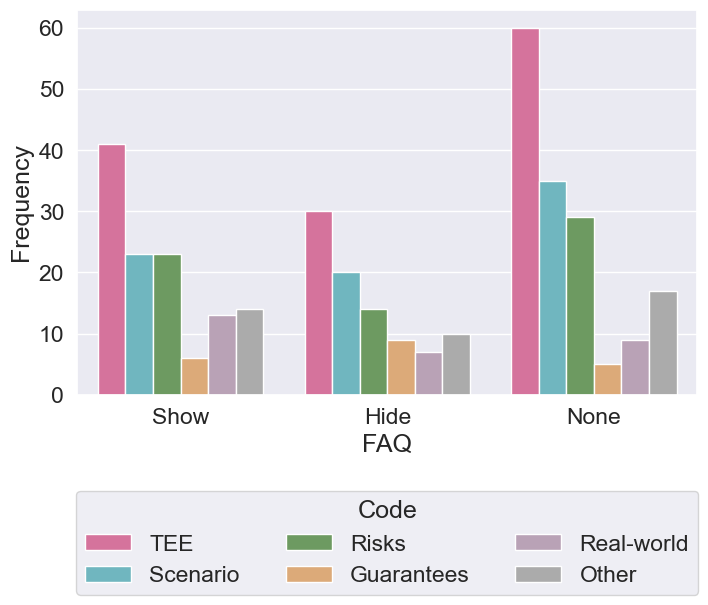

In [ ]:
faqs = ["Show", "Hide", "None"]
codes = ['gen', 'scenario', 'risk', 'guarantees', 'use', 'distrust']

df = pd.DataFrame()
for faq in faqs:
    for code in codes:
        df = pd.concat([df,
            pd.DataFrame({"FAQ": faq, 
                          "Code":code, 
                          "Frequency":all_faq_categories.loc[code,faq]},
                         index = [0])],
            ignore_index=True)

df.replace("gen","TEE", inplace=True)
df.replace("risk","Risks", inplace=True)
df.replace("use","Real-world", inplace=True)
df.replace("distrust","Other", inplace=True)
df.replace("scenario","Scenario", inplace=True)
df.replace("guarantees","Guarantees", inplace=True)

sns.set(font_scale=1.5)
sns.set_palette(['#E56399','#63C0CC','#68A357','#ECAA69','#BD9EB9','#ABABAB'], n_colors=6)
fig, ax = plt.subplots(figsize=(8, 5))
ax = sns.barplot(data=df, x="FAQ", y="Frequency", hue="Code", ax=ax)
sns.move_legend(ax, 'lower center', bbox_to_anchor=(0.5, -0.55), ncol=3)

In [ ]:
all_faq_codes = pd.DataFrame().reindex(surveyfieldsfollowup.qualCodes)
for (d,c) in zip(dfs,cols):
    all_faq_codes[c] = pd.DataFrame(d.sum(axis=1),columns=[c]).reindex(surveyfieldsfollowup.qualCodes).fillna(0)

print(all_faq_codes)

                        Show  Hide  None
Distrust:Vague          10.0   4.0   9.0
Distrust:TEE             1.0   1.0   4.0
Distrust:Scenario        2.0   4.0   3.0
Distrust:Manufactuerer   1.0   1.0   1.0
Risk:Hacking            12.0   5.0  11.0
Risk:People              5.0   3.0   4.0
Risk:General             5.0   4.0   9.0
Risk:Real                1.0   2.0   3.0
Risk:Fail                0.0   0.0   2.0
Risk:Tamper              0.0   0.0   0.0
Gen:Isolation            1.0   0.0   6.0
Gen:How?                 8.0   6.0  17.0
Gen:Auth                 1.0   0.0   0.0
Gen:Implementation       0.0   3.0  11.0
Gen:Features             0.0   0.0   0.0
Gen:Answered             1.0   0.0   0.0
Gen:Encryption           2.0   0.0   0.0
Gen:Tech                 1.0   4.0   3.0
Gen:Transmit             0.0   0.0   0.0
Gen:Misc                12.0   8.0   8.0
Gen:Password             1.0   1.0   0.0
Gen:Diff                 0.0   0.0   0.0
Gen:Open Source          1.0   2.0   0.0
Gen:What?       

In [ ]:
overall_qual = pd.concat([medical_qual_results.drop(["SCENARIO_Med", "FAQ"],axis=1),
                        iot_qual_results.drop(["SCENARIO_IoT", "FAQ"],axis=1)],axis=0)

hw_results = overall_qual.loc[overall_qual["EXPLN"] == "Hardware"].drop("EXPLN",axis=1)
trust_results = overall_qual.loc[overall_qual["EXPLN"] == "Trust"].drop("EXPLN",axis=1)
unsub_results = overall_qual.loc[overall_qual["EXPLN"] == "Unsubstantial"].drop("EXPLN",axis=1)
none_results = overall_qual.loc[overall_qual["EXPLN"] == "None"].drop("EXPLN",axis=1)

hw_code_counts = hw_results.apply(lambda col: col.value_counts()).fillna(0)
trust_code_counts = trust_results.apply(lambda col: col.value_counts()).fillna(0)
unsub_code_counts = unsub_results.apply(lambda col: col.value_counts()).fillna(0)
none_code_counts = none_results.apply(lambda col: col.value_counts()).fillna(0)

dfs = [
    hw_code_counts, 
    trust_code_counts, 
    unsub_code_counts, 
    none_code_counts
    ]

## merge medical and iot codes
for d in dfs:
    for cat in surveyfieldsfollowup.qualCategories:
        d[cat] = d["med_"+cat] + d["iot_"+cat]
        d.drop(["med_"+cat,"iot_"+cat], axis=1, inplace=True)

In [ ]:
# set up new dataframe with all qual codes
## need to re-index dataframes since we used med_ for medical codes and iot_ for iot codes
cols = ["Hardware", "Trust", "Unsub", "None"]

all_expln_categories = pd.DataFrame().reindex(surveyfieldsfollowup.qualCategories)
for (d,c) in zip(dfs,cols):
    all_expln_categories[c] = d.sum(axis=0).rename(index=dict(zip(d.columns, surveyfieldsfollowup.qualCategories)))

# combine rows where multiple codes from the same category were applied
all_expln_categories.loc['risk'] += all_expln_categories.loc['risk2']
all_expln_categories.loc['gen'] += all_expln_categories.loc['gen2']
all_expln_categories.loc['scenario'] += all_expln_categories.loc['scenario2']
all_expln_categories.drop(['risk2', 'gen2', 'scenario2'], inplace=True)

print(all_expln_categories)

            Hardware  Trust  Unsub  None
distrust        12.0   14.0    7.0   8.0
risk            15.0   19.0   14.0  18.0
gen             17.0   37.0   23.0  54.0
use              8.0    6.0    9.0   6.0
scenario        16.0   15.0   28.0  19.0
guarantees       2.0    5.0    7.0   6.0


In [ ]:
all_expln_codes = pd.DataFrame().reindex(surveyfieldsfollowup.qualCodes)
for (d,c) in zip(dfs,cols):
    all_expln_codes[c] = pd.DataFrame(d.sum(axis=1),columns=[c]).reindex(surveyfieldsfollowup.qualCodes).fillna(0)

print(all_expln_codes)

                        Hardware  Trust  Unsub  None
Distrust:Vague               6.0   10.0    3.0   4.0
Distrust:TEE                 2.0    1.0    2.0   1.0
Distrust:Scenario            3.0    2.0    2.0   2.0
Distrust:Manufactuerer       1.0    1.0    0.0   1.0
Risk:Hacking                10.0    6.0    6.0   6.0
Risk:People                  2.0    5.0    2.0   3.0
Risk:General                 2.0    5.0    5.0   6.0
Risk:Real                    1.0    1.0    1.0   3.0
Risk:Fail                    0.0    2.0    0.0   0.0
Risk:Tamper                  0.0    0.0    0.0   0.0
Gen:Isolation                3.0    3.0    0.0   1.0
Gen:How?                     3.0    4.0    8.0  16.0
Gen:Auth                     0.0    1.0    0.0   0.0
Gen:Implementation           2.0    8.0    1.0   3.0
Gen:Features                 0.0    0.0    0.0   0.0
Gen:Answered                 0.0    1.0    0.0   0.0
Gen:Encryption               0.0    1.0    0.0   1.0
Gen:Tech                     0.0    5.0    2.0

Aspects Qualitative data

In [ ]:
aspects_qual_results = pd.read_csv('./export_followup/qualitative_safety_data_coded.csv', encoding=ENCODING)

medical_qual_results = aspects_qual_results[["med_distrust", "med_distrust2", "med_trust", "med_trust2",
            "med_info", "med_misc", "SCENARIO_Med", "EXPLN", "FAQ"]]
iot_qual_results = aspects_qual_results[["iot_distrust", "iot_distrust2", "iot_trust", "iot_trust2",
            "iot_info", "iot_misc", "SCENARIO_IoT", "EXPLN", "FAQ"]]

medicalC_results_all = medical_qual_results.loc[medical_qual_results["SCENARIO_Med"] == "Medical-Complex"] \
    .drop(["SCENARIO_Med","EXPLN", "FAQ"],axis=1)
medicalS_results_all = medical_qual_results.loc[medical_qual_results["SCENARIO_Med"] == "Medical-Simple"] \
    .drop(["SCENARIO_Med","EXPLN", "FAQ"],axis=1)
iotC_results_all = iot_qual_results.loc[iot_qual_results["SCENARIO_IoT"] == "IoT-Complex"] \
    .drop(["SCENARIO_IoT","EXPLN", "FAQ"],axis=1)
iotS_results_all = iot_qual_results.loc[iot_qual_results["SCENARIO_IoT"] == "IoT-Simple"] \
    .drop(["SCENARIO_IoT","EXPLN", "FAQ"],axis=1)

In [ ]:
count_med_coded = medical_qual_results.drop(["EXPLN", "FAQ", "SCENARIO_Med"], axis=1)
count_iot_coded = iot_qual_results.drop(["EXPLN", "FAQ", "SCENARIO_IoT"], axis=1)

med_code_count = count_med_coded.count(axis=1).astype(bool).sum(axis=0)
iot_code_count = count_iot_coded.count(axis=1).astype(bool).sum(axis=0)

all_count = aspects_qual_results.drop(["ResponseId", "id", 
    "Which aspects of the scenario would make you feel that your data is safe or unsafe? (medical, other)", "SCENARIO_Med", 
    "safety-IoT", "SCENARIO_IoT", "EXPLN", "FAQ", "notes"], axis=1)

print("Total number of aspects coded: " + str(med_code_count + iot_code_count) 
      + " from " + str(all_count.count(axis=1).astype(bool).sum(axis=0)) + " people")

Total number of aspects coded: 660 from 382 people


In [ ]:
medicalC_code_counts = medicalC_results_all.apply(lambda col: col.value_counts()).fillna(0)
medicalS_code_counts = medicalS_results_all.apply(lambda col: col.value_counts()).fillna(0)
iotC_code_counts = iotC_results_all.apply(lambda col: col.value_counts()).fillna(0)
iotS_code_counts = iotS_results_all.apply(lambda col: col.value_counts()).fillna(0)

# set up new dataframe with all qual codes
## need to re-index dataframes since we used med_ for medical codes and iot_ for iot codes
all_categories = pd.DataFrame(medicalC_code_counts.sum(axis=0),columns=["Medical Complex"]) \
        .rename(index=dict(zip(medicalC_code_counts.columns, surveyfieldsfollowup.qualSafetyCategories))) \
    .join(pd.DataFrame(medicalS_code_counts.sum(axis=0),columns=["Medical Simple"]) \
        .rename(index=dict(zip(medicalS_code_counts.columns, surveyfieldsfollowup.qualSafetyCategories)))) \
    .join(pd.DataFrame(iotC_code_counts.sum(axis=0),columns=["IoT Complex"]) \
        .rename(index=dict(zip(iotC_code_counts.columns, surveyfieldsfollowup.qualSafetyCategories)))) \
    .join(pd.DataFrame(iotS_code_counts.sum(axis=0),columns=["IoT Simple"]) \
        .rename(index=dict(zip(iotS_code_counts.columns, surveyfieldsfollowup.qualSafetyCategories))))

print('Number of responses receiving at least one distrust code: ' + str(sum(all_categories.loc['distrust'])))
print('Number of responses receiving at least one trust code: ' + str(sum(all_categories.loc['trust'])))

# combine rows where multiple codes from the same category were applied
all_categories.loc['distrust'] += all_categories.loc['distrust2']
all_categories.loc['trust'] += all_categories.loc['trust2']
all_categories.drop(['distrust2', 'trust2'], inplace=True)

print(all_categories)

Number of responses receiving at least one distrust code: 392.0
Number of responses receiving at least one trust code: 249.0
          Medical Complex  Medical Simple  IoT Complex  IoT Simple
distrust            133.0           102.0        139.0       112.0
trust                64.0            73.0         54.0        74.0
info                 22.0            22.0         26.0        18.0
misc                 10.0             9.0         13.0        11.0


In [ ]:
# just medical vs IoT
med_iot_categories = all_categories.copy()
med_iot_categories["Medical Complex"] += med_iot_categories["Medical Simple"]
med_iot_categories["IoT Complex"] += med_iot_categories["IoT Simple"]
med_iot_categories.drop(["Medical Simple", "IoT Simple"], axis=1, inplace=True)
med_iot_categories.rename({"Medical Complex":"Medical", "IoT Complex":"IoT"}, axis=1, inplace=True)
med_iot_categories["Overall"] = med_iot_categories["Medical"] + med_iot_categories["IoT"]

print(med_iot_categories)

          Medical    IoT  Overall
distrust    235.0  251.0    486.0
trust       137.0  128.0    265.0
info         44.0   44.0     88.0
misc         19.0   24.0     43.0


In [ ]:
medicalC_code_counts = medicalC_results_all.apply(lambda col: col.value_counts()).reindex(surveyfieldsfollowup.qualSafetyCodes).fillna(0)
medicalS_code_counts = medicalS_results_all.apply(lambda col: col.value_counts()).reindex(surveyfieldsfollowup.qualSafetyCodes).fillna(0)
iotC_code_counts = iotC_results_all.apply(lambda col: col.value_counts()).reindex(surveyfieldsfollowup.qualSafetyCodes).fillna(0)
iotS_code_counts = iotS_results_all.apply(lambda col: col.value_counts()).reindex(surveyfieldsfollowup.qualSafetyCodes).fillna(0)

all_codes = pd.DataFrame(medicalC_code_counts.sum(axis=1),columns=["Medical Complex"]) \
    .join(pd.DataFrame(medicalS_code_counts.sum(axis=1),columns=["Medical Simple"])) \
    .join(pd.DataFrame(iotC_code_counts.sum(axis=1),columns=["IoT Complex"])) \
    .join(pd.DataFrame(iotS_code_counts.sum(axis=1),columns=["IoT Simple"]))


print(all_codes)

                             Medical Complex  Medical Simple  IoT Complex  IoT Simple
Distrust:Vague                           5.0             3.0          4.0         3.0
Distrust:Gen                            19.0            11.0         13.0        11.0
Distrust:Hacker                         18.0            13.0         10.0        11.0
Distrust:Breaches                       11.0            11.0         13.0         7.0
Distrust:Unnecessary                     4.0             6.0          1.0        13.0
Distrust:Future Use                     10.0             9.0          3.0         6.0
Distrust:AI                             12.0             0.0          6.0         1.0
Distrust:Bug                             3.0             2.0          6.0         3.0
Distrust:Sell                            0.0             2.0          8.0         2.0
Distrust:Transmission/Store              0.0             2.0          2.0         3.0
Distrust:Lie                             1.0          

In [ ]:
all_codes["Medical Complex"] += all_codes["Medical Simple"]
all_codes["IoT Complex"] += all_codes["IoT Simple"]
all_codes.drop(["Medical Simple", "IoT Simple"], axis=1, inplace=True)
all_codes.rename({"Medical Complex":"Medical", "IoT Complex":"IoT"}, axis=1, inplace=True)
all_codes["Overall"] = all_codes["Medical"] + all_codes["IoT"]

print(all_codes)

                             Medical   IoT  Overall
Distrust:Vague                   8.0   7.0     15.0
Distrust:Gen                    30.0  24.0     54.0
Distrust:Hacker                 31.0  21.0     52.0
Distrust:Breaches               22.0  20.0     42.0
Distrust:Unnecessary            10.0  14.0     24.0
Distrust:Future Use             19.0   9.0     28.0
Distrust:AI                     12.0   7.0     19.0
Distrust:Bug                     5.0   9.0     14.0
Distrust:Sell                    2.0  10.0     12.0
Distrust:Transmission/Store      2.0   5.0      7.0
Distrust:Lie                     1.0   4.0      5.0
Distrust:Research                2.0   3.0      5.0
Distrust:"Trust"                 2.0   1.0      3.0
Distrust:Inference               1.0   1.0      2.0
Distrust:Repeat Data            39.0  43.0     82.0
Distrust:Repeat TEE              5.0   1.0      6.0
Distrust:Repeat Destination      7.0  32.0     39.0
Distrust:Repeat Purpose          4.0   6.0     10.0
Distrust:Rep